In [1]:
# =============================================================================
#  INSTITUTO POLITÉCNICO NACIONAL - ESCUELA SUPERIOR DE CÓMPUTO
#  Unidad de aprendizaje : Analítica y Visualización de Datos
#  Profesor              : Ituriel Enrique Flores Estrada
#  Prácticas 1 y 2       : Análisis exploratorio, integración, limpieza y
#                          transformación de datos, e ingeniería de características
#  Sección A             : Análisis exploratorio de datos (EDA) inicial
# -----------------------------------------------------------------------------
#  I.   Nombre completo del estudiante : Ricardo González Manzano
#  II.  Grupo                          : 5AV1
#  III. Carrera                        : Licenciatura en Ciencia de Datos
#  IV.  Fecha de última modificación   : 04/10/2026
# -----------------------------------------------------------------------------
#  V.   DESCRIPCIÓN DE LA FUNCIONALIDAD
#  Este notebook realiza el Análisis Exploratorio de Datos (EDA) inicial de los
#  datasets "CarDekho" (Kaggle, manishkr1754/cardekho-used-car-data) y
#  "Automobile" (UCI Machine Learning Repository, id = 10), antes de cualquier
#  integración, limpieza o transformación. Cubre:
#    1. Datos generales: diccionario de cada dimensión (significado, tipo
#       cualitativo/cuantitativo, tipo de dato, unidad de medida) y despliegue
#       de los 10 primeros y 10 últimos registros.
#    2. Análisis numérico: total de observaciones, nulos (cantidad y %),
#       dimensiones cuantitativas almacenadas como texto, dimensiones con
#       unidades o caracteres adicionales, inconsistencias en dimensiones
#       cualitativas, clases y frecuencias, y estadística descriptiva
#       (media, mediana, moda, desviación estándar, varianza, mínimo, máximo,
#       rango y cuartiles).
#    3. Análisis gráfico: distribuciones cuantitativas, pairplot (bivariado),
#       mapa de calor de correlación (multivariado), distribuciones
#       cualitativas y comparación de cada dimensión categórica contra el
#       precio (agrupado y ordenado de mayor a menor).
#  Los datos originales nunca se modifican: se trabaja sobre copias con los
#  nombres en español definidos en src/homologacion.py. Las figuras se guardan
#  en la carpeta figuras/ con el prefijo "figura_A".
#
#  PARÁMETROS DE EJECUCIÓN
#  El notebook no recibe parámetros. Requisitos para su correcta ejecución:
#    - Abrirse desde la carpeta Practica01 (usa las rutas relativas src/ y
#      figuras/).
#    - Tener instaladas las dependencias de src/requirements.txt.
#    - Conexión a internet en la primera ejecución: los datasets se descargan
#      con hm.cargar_cardekho() (kagglehub) y hm.cargar_uci() (ucimlrepo).
#
#  FUNCIONES DESARROLLADAS
#  - describir_dimensiones(df: pd.DataFrame, descripciones: dict,
#        renombrar: dict) -> pd.DataFrame
#        Diccionario de dimensiones: une la descripción documental (significado,
#        representación y unidad) con el tipo de dato real en pandas.
#  - columnas_por_representacion(diccionario: pd.DataFrame, prefijo: str,
#        como_texto: bool | None) -> list
#        Lista las dimensiones (en español) según su representación y, si se
#        pide, según estén guardadas como texto o como número.
#  - resumen_nulos(df: pd.DataFrame) -> pd.DataFrame
#        Total de observaciones, nulos, porcentaje de nulos y nulos ocultos
#        (p. ej. "?", "" o "NA") por dimensión.
#  - detectar_texto_cuantitativo(df: pd.DataFrame) -> pd.DataFrame
#        Porcentaje de valores que son números con dígitos, números escritos
#        con palabras o números con unidad, y diagnóstico por dimensión.
#  - inconsistencias_cualitativas(df: pd.DataFrame, columnas: list)
#        -> pd.DataFrame
#        Detecta espacios innecesarios, diferencias de mayúsculas/minúsculas o
#        de separadores y clases que son el inicio de otra (nombres truncados).
#  - distribucion_clases(serie: pd.Series) -> pd.DataFrame
#        Cantidad y porcentaje de observaciones por clase.
#  - estadisticos_cuantitativos(df: pd.DataFrame, columnas: list)
#        -> pd.DataFrame
#        Media, mediana, moda, desv. estándar, varianza, mín, máx, rango,
#        cuartiles e IQR de cada dimensión cuantitativa.
#  - formato_compacto(valor: float, _posicion) -> str
#        Abrevia números grandes en los ejes de las gráficas (k, M).
#  - guardar_figura(fig: Figure, nombre_archivo: str) -> str
#        Guarda una figura en la carpeta figuras/ y regresa su ruta.
#  - crear_mosaico(columnas: list, n_clases: dict, umbral: int,
#        alto_ancha: float, alto_angosta: float) -> tuple
#        Acomoda una subgráfica por dimensión según su número de clases;
#        regresa (Figure, dict de Axes).
#  - graficar_distribuciones_cuantitativas(df: pd.DataFrame, columnas: list,
#        unidades: dict, titulo: str, archivo: str) -> Figure
#        Histograma con densidad (KDE), media y mediana por dimensión.
#  - graficar_pairplot(df: pd.DataFrame, columnas: list, titulo: str,
#        archivo: str, altura: float) -> PairGrid
#        Pairplot (análisis bivariado).
#  - graficar_mapa_calor(df: pd.DataFrame, columnas: list, titulo: str,
#        archivo: str) -> pd.DataFrame
#        Mapa de calor de la correlación de Pearson; regresa la matriz.
#  - graficar_distribuciones_cualitativas(df: pd.DataFrame, columnas: list,
#        titulo: str, archivo: str, max_clases: int) -> Figure
#        Gráficas de barras de frecuencias por categoría.
#  - precio_por_categoria(df: pd.DataFrame, categoria: str, precio: str)
#        -> pd.DataFrame
#        Observaciones, precio promedio y mediano por categoría, ordenado de
#        mayor a menor precio promedio.
#  - graficar_categorias_vs_precio(df: pd.DataFrame, columnas: list,
#        precio: str, unidad_precio: str, titulo: str, archivo: str,
#        max_clases: int) -> Figure
#        Precio promedio por categoría, ordenado de mayor a menor.
# =============================================================================

In [2]:
# =====================================================================
# Propósito: importar librerías, el módulo del equipo (homologacion.py)
#            y configurar cómo se muestran las tablas y las gráficas.
# Entrada:   ninguna.
# Salida:    entorno listo y carpeta "figuras/" creada.
# =====================================================================
import os                          # Rutas y creación de carpetas
import re                          # Expresiones regulares para revisar texto
import sys                         # Agregar "src" a las rutas de búsqueda de módulos

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker  # Formato de los números en los ejes
import seaborn as sns
from IPython.display import display  # Mostrar varias tablas en una misma celda

# Módulo del equipo: carga de datasets y diccionarios de renombrado a español.
sys.path.append("src")
import homologacion as hm

# Tablas: mostrar todas las columnas y hasta 200 filas sin recortarlas.
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", None)  # Sin recortar textos largos
pd.set_option("display.float_format", "{:,.3f}".format)  # 3 decimales y separador de miles

# Estilo de las gráficas: fondo claro y cuadrícula tenue para que destaquen los datos.
sns.set_theme(style="whitegrid", rc={
    "grid.color": "#e6e5e1", "axes.edgecolor": "#b9b8b3",
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
})
COLOR_PRINCIPAL = "#2a78d6"  # Azul: frecuencias y distribuciones
COLOR_PRECIO = "#eb6834"     # Naranja: gráficas contra el precio
COLOR_TEXTO = "#52514e"      # Gris oscuro: líneas de referencia (media/mediana)

CARPETA_FIGURAS = "figuras"
os.makedirs(CARPETA_FIGURAS, exist_ok=True)

## Funciones del análisis
Las funciones se definen aquí para reutilizarlas con ambos datasets y en el EDA final (Sección G). Cada una indica en su docstring su propósito, sus parámetros y lo que regresa.

In [3]:
# =====================================================================
# Propósito: funciones de los incisos A.1 y A.2 (descripción de las
#            dimensiones, nulos, texto cuantitativo, inconsistencias,
#            clases y estadísticos).
# Entrada:   ninguna (solo se definen funciones y constantes).
# Salida:    funciones disponibles para el resto del notebook.
# =====================================================================

# Valores de texto que en la práctica significan "dato faltante" aunque
# pandas no los reconozca como nulos.
NULOS_OCULTOS = {"?", "", "na", "n/a", "nan", "null", "none", "-"}

# Números escritos con palabras (UCI guarda puertas y cilindros así).
PALABRAS_NUMERO = {"zero": 0, "one": 1, "two": 2, "three": 3, "four": 4, "five": 5,
                   "six": 6, "seven": 7, "eight": 8, "nine": 9, "ten": 10,
                   "eleven": 11, "twelve": 12}

# Número seguido de una unidad o símbolo, por ejemplo "1197 CC", "18.9 kmpl", "90 bhp".
# ^\s*-?\d+([.,]\d+)?  -> número entero o decimal al inicio
# \s*[^\d\s.,-].*$     -> después viene algo que no es número (la unidad)
PATRON_NUMERO_CON_UNIDAD = re.compile(r"^\s*-?\d+(?:[.,]\d+)?\s*[^\d\s.,-].*$")


def describir_dimensiones(df, descripciones, renombrar):
    """Construye el diccionario de dimensiones de un dataset.

    Parámetros:
        df (DataFrame): dataset original, sin modificar.
        descripciones (dict): {columna: (descripción, representación, unidad)},
            escrito a partir de la documentación de cada fuente.
        renombrar (dict): {columna: nombre en español} (de homologacion.py).
    Regresa:
        DataFrame con una fila por dimensión. El tipo de dato, los valores
        distintos y el ejemplo se calculan de los datos, no se escriben a mano.
    """
    filas = []
    for col in df.columns:
        descripcion, representacion, unidad = descripciones[col]
        no_nulos = df[col].dropna()
        filas.append({
            "Dimensión original": col,
            "Nombre en español": renombrar.get(col, col),
            "Descripción": descripcion,
            "Representación": representacion,
            "Tipo de dato": str(df[col].dtype),   # int64, float64 o str
            "Unidad de medida": unidad,
            "Valores distintos": df[col].nunique(),
            "Ejemplo": no_nulos.iloc[0] if len(no_nulos) else None,
        })
    return pd.DataFrame(filas)


def columnas_por_representacion(diccionario, prefijo, como_texto=None):
    """Lista las dimensiones (en español) cuya representación empieza con "prefijo".

    Parámetros:
        diccionario (DataFrame): resultado de describir_dimensiones().
        prefijo (str): "Cuantitativa", "Cualitativa" o "Identificador".
        como_texto (bool o None): True -> solo las guardadas como texto;
            False -> solo las guardadas como número; None -> todas.
    Regresa:
        list[str] con los nombres en español, en el orden original.
    """
    mascara = diccionario["Representación"].str.startswith(prefijo)
    if como_texto is not None:
        es_texto = ~diccionario["Tipo de dato"].isin(["int64", "float64"])
        mascara &= es_texto if como_texto else ~es_texto
    return diccionario.loc[mascara, "Nombre en español"].tolist()


def resumen_nulos(df):
    """Total de observaciones, nulos y nulos ocultos de cada dimensión.

    Parámetros:
        df (DataFrame): dataset a revisar.
    Regresa:
        DataFrame con una fila por dimensión. "Nulos ocultos" cuenta textos
        como '?', '' o 'NA' que representan un faltante sin ser NaN.
    """
    total = len(df)
    nulos = df.isna().sum()
    ocultos = {}
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            ocultos[col] = 0  # Una columna numérica no puede contener texto
        else:
            texto = df[col].dropna().astype(str).str.strip().str.lower()
            ocultos[col] = int(texto.isin(NULOS_OCULTOS).sum())
    tabla = pd.DataFrame({
        "Total de observaciones": total,
        "No nulos": total - nulos,
        "Nulos": nulos,
        "% nulos": nulos / total * 100,
        "Nulos ocultos": pd.Series(ocultos),
    })
    return tabla.rename_axis("Dimensión")


def detectar_texto_cuantitativo(df):
    """Revisa si cada dimensión guarda números como texto o con unidades.

    Para cada columna de texto calcula el porcentaje de valores (no nulos) que:
      - se convierten directamente a número ("3", "4.5");
      - son números escritos con palabras ("two", "four");
      - son un número seguido de una unidad o símbolo ("1197 CC", "90 bhp").
    Parámetros:
        df (DataFrame): dataset a revisar.
    Regresa:
        DataFrame con los porcentajes y un diagnóstico por dimensión.
    """
    filas = []
    for col in df.columns:
        serie = df[col].dropna()
        if pd.api.types.is_numeric_dtype(serie):
            filas.append({"Dimensión": col, "Tipo de dato": str(df[col].dtype),
                          "% número directo": 100.0, "% número en palabras": 0.0,
                          "% número con unidad": 0.0, "Ejemplos": "",
                          "Diagnóstico": "Numérica: sin unidades ni caracteres adicionales"})
            continue
        texto = serie.astype(str).str.strip()
        # errors="coerce" convierte en NaN lo que no es número; notna() marca los que sí lo son.
        pct_num = pd.to_numeric(texto, errors="coerce").notna().mean() * 100
        pct_pal = texto.str.lower().isin(PALABRAS_NUMERO).mean() * 100
        pct_uni = texto.str.match(PATRON_NUMERO_CON_UNIDAD).mean() * 100
        if pct_num + pct_pal >= 90:
            forma = "con palabras" if pct_pal > pct_num else "con dígitos"
            diagnostico = f"Cuantitativa guardada como texto ({forma})"
        elif pct_uni >= 50:
            diagnostico = "Cuantitativa con unidades o caracteres adicionales"
        else:
            diagnostico = "Cualitativa: texto propio de la categoría"
        filas.append({"Dimensión": col, "Tipo de dato": str(df[col].dtype),
                      "% número directo": pct_num, "% número en palabras": pct_pal,
                      "% número con unidad": pct_uni,
                      "Ejemplos": ", ".join(texto.unique()[:4]),
                      "Diagnóstico": diagnostico})
    return pd.DataFrame(filas).set_index("Dimensión")


def inconsistencias_cualitativas(df, columnas):
    """Busca problemas de representación en dimensiones cualitativas.

    Revisa cuatro casos:
      1. Clases con espacios al inicio o al final, o con espacios dobles.
      2. Clases que solo difieren en mayúsculas/minúsculas ("ISUZU" vs "Isuzu").
      3. Clases que solo difieren en separadores ("RediGO" vs "redi-GO").
      4. Clases cuyo texto completo es el inicio de otra clase ("CR" y "CR-V"):
         posibles nombres truncados o versiones del mismo concepto.
    Parámetros:
        df (DataFrame): dataset a revisar.
        columnas (list): dimensiones cualitativas guardadas como texto.
    Regresa:
        DataFrame con una fila por dimensión y los hallazgos de cada caso.
    """
    filas = []
    for col in columnas:
        clases = pd.Series(df[col].dropna().astype(str).unique())
        # Caso 1: espacios innecesarios.
        espacios = clases[(clases != clases.str.strip()) | clases.str.contains("  ")]
        # Caso 2: se agrupan las clases por su versión en minúsculas; si un
        # grupo tiene más de una clase, esas clases solo difieren en mayúsculas.
        minus = clases.str.strip().str.lower()
        grupos_may = [" / ".join(g) for _, g in clases.groupby(minus) if len(g) > 1]
        # Caso 3: además se quitan guiones, guiones bajos y espacios.
        clave = minus.str.replace(r"[-_\s]+", "", regex=True)
        grupos_sep = [" / ".join(g) for _, g in clases.groupby(clave)
                      if len(g) > 1 and g.str.lower().nunique() > 1]
        # Caso 4: se compara cada par de clases normalizadas; si una es el
        # comienzo exacto de la otra (y no son iguales) se reporta el par.
        unicas = dict(zip(clave, clases))  # clave normalizada -> texto original
        prefijos = [f"{unicas[a]} ⊂ {unicas[b]}"
                    for a in unicas for b in unicas
                    if a != b and len(a) >= 2 and b.startswith(a)]
        filas.append({
            "Dimensión": col,
            "Clases": len(clases),
            "Con espacios innecesarios": ", ".join(espacios) or "—",
            "Difieren solo en mayúsculas": "; ".join(grupos_may) or "—",
            "Difieren en separadores": "; ".join(grupos_sep) or "—",
            "Una clase es el inicio de otra": "; ".join(sorted(prefijos)) or "—",
        })
    return pd.DataFrame(filas).set_index("Dimensión")


def distribucion_clases(serie):
    """Frecuencia y porcentaje de cada clase de una dimensión.

    Parámetros:
        serie (Series): dimensión cualitativa (o discreta) a contar.
    Regresa:
        DataFrame ordenado de mayor a menor frecuencia. Los nulos aparecen
        como la clase "(nulo)" para no ocultarlos. El porcentaje se calcula
        sobre el total de observaciones.
    """
    conteo = serie.value_counts(dropna=False)
    conteo.index = conteo.index.map(lambda v: "(nulo)" if pd.isna(v) else v)
    return pd.DataFrame({"Observaciones": conteo,
                         "% del total": conteo / len(serie) * 100}).rename_axis(serie.name)


def estadisticos_cuantitativos(df, columnas):
    """Medidas descriptivas de las dimensiones cuantitativas (sin contar nulos).

    Parámetros:
        df (DataFrame): dataset.
        columnas (list): dimensiones cuantitativas guardadas como número.
    Regresa:
        DataFrame con media, mediana, moda, desviación estándar, varianza,
        mínimo, máximo, rango, cuartiles y rango intercuartílico (IQR).
    """
    filas = []
    for col in columnas:
        s = df[col].dropna()
        modas = s.mode()  # Puede haber más de una moda; se reporta la primera y cuántas hay
        q1, q2, q3 = s.quantile([0.25, 0.50, 0.75])
        filas.append({
            "Dimensión": col, "Observaciones": s.count(),
            "Media": s.mean(), "Mediana": s.median(),
            "Moda": modas.iloc[0], "N.º de modas": len(modas),
            "Desv. estándar": s.std(), "Varianza": s.var(),  # Muestrales (ddof=1)
            "Mínimo": s.min(), "Máximo": s.max(), "Rango": s.max() - s.min(),
            "Q1 (25 %)": q1, "Q2 (50 %)": q2, "Q3 (75 %)": q3, "IQR": q3 - q1,
        })
    return pd.DataFrame(filas).set_index("Dimensión")

In [4]:
# =====================================================================
# Propósito: funciones del inciso A.3 (gráficas). Cada una guarda su
#            figura en "figuras/" para usarla en el reporte.
# Entrada:   ninguna (solo se definen funciones).
# Salida:    funciones disponibles para el resto del notebook.
# =====================================================================

def formato_compacto(valor, _posicion=None):
    """Escribe números grandes de forma corta para los ejes (2,500,000 -> "2.5 M").

    Parámetros:
        valor (float): número a escribir.
        _posicion: posición de la marca en el eje (la pide matplotlib; no se usa).
    Regresa:
        str con el número abreviado (k = miles, M = millones).
    """
    if abs(valor) >= 1e6:
        return f"{valor / 1e6:g} M"
    if abs(valor) >= 1e4:
        return f"{valor / 1e3:g} k"
    return f"{valor:,.0f}" if abs(valor) >= 1000 else f"{valor:g}"


def guardar_figura(fig, nombre_archivo):
    """Guarda una figura en la carpeta de figuras del reporte.

    Parámetros:
        fig (Figure): figura de matplotlib.
        nombre_archivo (str): nombre del PNG, por ejemplo "figura_A1_x.png".
    Regresa:
        str con la ruta donde quedó guardada.
    """
    ruta = os.path.join(CARPETA_FIGURAS, nombre_archivo)
    fig.savefig(ruta, dpi=150, bbox_inches="tight")  # "tight" evita que se corten etiquetas
    return ruta


def crear_mosaico(columnas, n_clases, umbral=12, alto_ancha=4.2, alto_angosta=3.4):
    """Acomoda una subgráfica por dimensión según su número de clases.

    Las dimensiones con más de "umbral" clases ocupan un renglón completo
    (necesitan espacio para sus etiquetas); las demás se acomodan de tres en tres.
    Parámetros:
        columnas (list): dimensiones a graficar.
        n_clases (dict): {dimensión: número de barras que tendrá}.
        umbral (int): número de clases a partir del cual va a todo lo ancho.
        alto_ancha, alto_angosta (float): alto en pulgadas de cada tipo de renglón.
    Regresa:
        tuple (Figure, dict {dimensión: Axes}).
    """
    anchas = [c for c in columnas if n_clases[c] > umbral]
    angostas = [c for c in columnas if n_clases[c] <= umbral]
    mosaico = [[c, c, c] for c in anchas]
    for i in range(0, len(angostas), 3):
        fila = angostas[i:i + 3]
        mosaico.append(fila + ["."] * (3 - len(fila)))  # "." deja el hueco vacío
    alturas = [alto_ancha] * len(anchas) + [alto_angosta] * (len(mosaico) - len(anchas))
    fig, ejes = plt.subplot_mosaic(mosaico, figsize=(16, sum(alturas)),
                                   gridspec_kw={"height_ratios": alturas})
    return fig, ejes


def graficar_distribuciones_cuantitativas(df, columnas, unidades, titulo, archivo):
    """Histograma con curva de densidad (KDE) de cada dimensión cuantitativa.

    Las líneas punteadas marcan la media (--) y la mediana (:); si están
    separadas, la distribución es asimétrica.
    Parámetros:
        df (DataFrame), columnas (list): datos y dimensiones a graficar.
        unidades (dict): {dimensión: unidad} para el eje X.
        titulo (str), archivo (str): título general y nombre del PNG.
    Regresa:
        Figure de matplotlib.
    """
    ncols = 3
    nfilas = int(np.ceil(len(columnas) / ncols))
    fig, ejes = plt.subplots(nfilas, ncols, figsize=(16, 3.6 * nfilas))
    ejes = np.atleast_1d(ejes).ravel()  # Arreglo plano para recorrerlo con zip
    for eje, col in zip(ejes, columnas):
        datos = df[col].dropna()
        # Discreta = enteros en un rango corto (p. ej. años o asientos): una barra por valor.
        # RPM_Maximas tiene pocos valores, pero separados por cientos: se trata como continua.
        discreta = bool((datos % 1 == 0).all() and datos.max() - datos.min() <= 30)
        sns.histplot(datos, ax=eje, kde=not discreta, discrete=discreta,
                     bins="auto" if discreta else 40, color=COLOR_PRINCIPAL,
                     edgecolor="white", linewidth=0.4)
        eje.axvline(datos.mean(), color=COLOR_TEXTO, ls="--", lw=1.2, label="Media")
        eje.axvline(datos.median(), color=COLOR_TEXTO, ls=":", lw=1.6, label="Mediana")
        eje.set_title(col)
        eje.set_xlabel(unidades.get(col, ""))
        eje.set_ylabel("Frecuencia")
        eje.xaxis.set_major_formatter(mticker.FuncFormatter(formato_compacto))
    for eje in ejes[len(columnas):]:
        eje.set_visible(False)  # Oculta los espacios sobrantes de la cuadrícula
    ejes[0].legend(fontsize=8)
    fig.suptitle(titulo, fontsize=13, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.98))
    guardar_figura(fig, archivo)
    return fig


def graficar_pairplot(df, columnas, titulo, archivo, altura=2.0):
    """Pairplot: dispersión entre cada par de dimensiones cuantitativas.

    En la diagonal se muestra el histograma de cada dimensión.
    Parámetros:
        df (DataFrame), columnas (list): datos y dimensiones a comparar.
        titulo (str), archivo (str): título y nombre del PNG.
        altura (float): tamaño en pulgadas de cada subgráfica.
    Regresa:
        PairGrid de seaborn.
    """
    rejilla = sns.pairplot(df[columnas], height=altura, diag_kind="hist",
                           plot_kws={"s": 9, "alpha": 0.35, "color": COLOR_PRINCIPAL,
                                     "edgecolor": "none"},
                           diag_kws={"color": COLOR_PRINCIPAL, "edgecolor": "none", "bins": 30})
    # Números grandes abreviados (k, M) en lugar de notación científica (1e6).
    for eje in rejilla.axes.flat:
        eje.xaxis.set_major_formatter(mticker.FuncFormatter(formato_compacto))
        eje.yaxis.set_major_formatter(mticker.FuncFormatter(formato_compacto))
    rejilla.figure.suptitle(titulo, y=1.01, fontsize=14, fontweight="bold")
    guardar_figura(rejilla.figure, archivo)
    return rejilla


def graficar_mapa_calor(df, columnas, titulo, archivo):
    """Mapa de calor de la correlación de Pearson entre dimensiones cuantitativas.

    Solo se dibuja el triángulo inferior porque la matriz es simétrica.
    Rojo = correlación positiva, azul = negativa, blanco = sin correlación.
    Parámetros:
        df (DataFrame), columnas (list): datos y dimensiones.
        titulo (str), archivo (str): título y nombre del PNG.
    Regresa:
        DataFrame con la matriz de correlación completa.
    """
    corr = df[columnas].corr(method="pearson")
    mascara = np.triu(np.ones_like(corr, dtype=bool), k=1)  # True = celda oculta
    lado = max(7, 0.62 * len(columnas) + 2)
    fig, eje = plt.subplots(figsize=(lado, lado * 0.82))
    sns.heatmap(corr, mask=mascara, annot=True, fmt=".2f", cmap="RdBu_r",
                vmin=-1, vmax=1, center=0, square=True, linewidths=0.6,
                linecolor="white", annot_kws={"size": 8}, ax=eje,
                cbar_kws={"shrink": 0.7, "label": "Coeficiente de correlación de Pearson"})
    eje.set_title(titulo, fontsize=13, fontweight="bold", pad=12)
    fig.tight_layout()
    guardar_figura(fig, archivo)
    return corr


def graficar_distribuciones_cualitativas(df, columnas, titulo, archivo, max_clases=30):
    """Barras con la frecuencia de cada clase de las dimensiones cualitativas.

    Si una dimensión tiene más de "max_clases" clases, se grafican las más
    frecuentes y el resto se agrupa en una barra "Otras (k clases)".
    Parámetros:
        df (DataFrame), columnas (list): datos y dimensiones.
        titulo (str), archivo (str): título y nombre del PNG.
        max_clases (int): número máximo de barras individuales.
    Regresa:
        Figure de matplotlib.
    """
    conteos = {}
    for col in columnas:
        conteo = df[col].astype("string").fillna("(nulo)").value_counts()
        if len(conteo) > max_clases:
            resto = conteo.iloc[max_clases:]
            conteo = pd.concat([conteo.iloc[:max_clases],
                                pd.Series({f"Otras ({len(resto)} clases)": resto.sum()})])
        conteos[col] = conteo
    fig, ejes = crear_mosaico(columnas, {c: len(v) for c, v in conteos.items()})
    for col, conteo in conteos.items():
        eje = ejes[col]
        etiquetas = [str(v) for v in conteo.index]
        eje.bar(range(len(conteo)), conteo.values, color=COLOR_PRINCIPAL, width=0.75)
        eje.set_xticks(range(len(conteo)))
        muchas = len(conteo) > 6
        eje.set_xticklabels(etiquetas, rotation=60 if muchas else 0, ha="right" if muchas else "center")
        if len(conteo) <= 12:  # Con pocas barras se escribe el porcentaje encima
            pct = conteo.values / len(df) * 100
            for x, (v, p) in enumerate(zip(conteo.values, pct)):
                eje.text(x, v, f"{p:.1f} %", ha="center", va="bottom", fontsize=8, color=COLOR_TEXTO)
            eje.margins(y=0.15)
        eje.set_title(f"{col} ({df[col].nunique()} clases)")
        eje.set_ylabel("Observaciones")
        eje.yaxis.set_major_formatter(mticker.FuncFormatter(formato_compacto))
    fig.suptitle(titulo, fontsize=14, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.985))  # Deja espacio al título general
    guardar_figura(fig, archivo)
    return fig


def precio_por_categoria(df, categoria, precio):
    """Agrupa las observaciones por categoría y ordena por precio promedio.

    Parámetros:
        df (DataFrame): dataset.
        categoria (str): dimensión categórica (eje X).
        precio (str): dimensión de precio (eje Y).
    Regresa:
        DataFrame con observaciones, precio promedio y precio mediano por
        categoría, de mayor a menor precio promedio. Los nulos de precio se
        excluyen del promedio.
    """
    tabla = (df.groupby(categoria)[precio]
               .agg(Observaciones="count", **{"Precio promedio": "mean",
                                                "Precio mediano": "median"})
               .sort_values("Precio promedio", ascending=False))
    return tabla


def graficar_categorias_vs_precio(df, columnas, precio, unidad_precio, titulo, archivo, max_clases=30):
    """Barras del precio promedio por categoría, de mayor a menor.

    Eje X: clases de la dimensión categórica; eje Y: precio promedio.
    Si hay más de "max_clases" clases, se muestran las "max_clases" más caras.
    Parámetros:
        df (DataFrame), columnas (list), precio (str): datos, categóricas y precio.
        unidad_precio (str): unidad para el eje Y (p. ej. "INR").
        titulo (str), archivo (str): título y nombre del PNG.
        max_clases (int): número máximo de barras por dimensión.
    Regresa:
        Figure de matplotlib.
    """
    tablas = {c: precio_por_categoria(df, c, precio)["Precio promedio"] for c in columnas}
    fig, ejes = crear_mosaico(columnas, {c: min(len(t), max_clases) for c, t in tablas.items()})
    for col, serie in tablas.items():
        total = len(serie)
        serie = serie.iloc[:max_clases]
        eje = ejes[col]
        eje.bar(range(len(serie)), serie.values, color=COLOR_PRECIO, width=0.75)
        eje.set_xticks(range(len(serie)))
        muchas = len(serie) > 6
        eje.set_xticklabels([str(v) for v in serie.index], rotation=60 if muchas else 0,
                            ha="right" if muchas else "center")
        sufijo = f" — {max_clases} más caras de {total}" if total > max_clases else ""
        eje.set_title(f"{col}{sufijo}")
        eje.set_ylabel(f"{precio} promedio ({unidad_precio})")
        eje.yaxis.set_major_formatter(mticker.FuncFormatter(formato_compacto))
    fig.suptitle(titulo, fontsize=14, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.985))  # Deja espacio al título general
    guardar_figura(fig, archivo)
    return fig

## A.1 Datos generales
### Carga de los datasets
Los datasets no se guardan en el repositorio. Se descargan por código con las funciones de src/homologacion.py:
- CarDekho (dataset principal): hm.cargar_cardekho(), con kagglehub.
- UCI Automobile (segunda fuente): hm.cargar_uci(), con ucimlrepo (id = 10).

In [5]:
# =====================================================================
# Propósito: descargar ambos datasets y mostrar sus dimensiones.
# Entrada:   Kaggle (CarDekho) y UCI ML Repository (Automobile).
# Salida:    DataFrames cd_raw y uci_raw (datos crudos, nunca se modifican).
# =====================================================================
cd_raw = hm.cargar_cardekho()
uci_raw = hm.cargar_uci()

# shape = (registros, dimensiones)
print(f"CarDekho       : {cd_raw.shape[0]:,} registros × {cd_raw.shape[1]} dimensiones")
print(f"UCI Automobile : {uci_raw.shape[0]:,} registros × {uci_raw.shape[1]} dimensiones")

CarDekho       : 15,411 registros × 14 dimensiones
UCI Automobile : 205 registros × 26 dimensiones


### Características de cada dimensión
La descripción, la representación y la unidad de medida se escribieron a partir de la documentación de cada fuente (Kaggle y UCI). El tipo de dato, los valores distintos y el ejemplo se calculan directamente de los datos.

Representación:
- Cuantitativa continua: medición que puede tomar cualquier valor en un intervalo.
- Cuantitativa discreta: conteo con valores enteros.
- Cualitativa nominal: categorías sin orden.
- Cualitativa ordinal: categorías con orden.
- Identificador: solo distingue registros.

Tipo de dato: int64 es entero, float64 es número decimal (también se usa cuando una columna entera tiene nulos) y str es texto.

In [6]:
# =====================================================================
# Propósito: diccionario de dimensiones de CarDekho.
# Entrada:   cd_raw y la documentación del dataset en Kaggle.
# Salida:    DataFrame dicc_cd (una fila por dimensión).
# =====================================================================
# {columna original: (descripción, representación, unidad de medida)}
DESCRIPCION_CARDEKHO = {
    "Unnamed: 0":        ("Índice de fila heredado al exportar el CSV; no describe al vehículo", "Identificador", "—"),
    "car_name":          ("Nombre comercial del vehículo (marca + modelo)", "Cualitativa nominal", "—"),
    "brand":             ("Fabricante o marca del vehículo", "Cualitativa nominal", "—"),
    "model":             ("Modelo del vehículo dentro de su marca", "Cualitativa nominal", "—"),
    "vehicle_age":       ("Antigüedad del vehículo al publicarse el anuncio", "Cuantitativa discreta", "años"),
    "km_driven":         ("Distancia total recorrida por el vehículo", "Cuantitativa continua", "km"),
    "seller_type":       ("Tipo de vendedor que publica el anuncio", "Cualitativa nominal", "—"),
    "fuel_type":         ("Tipo de combustible", "Cualitativa nominal", "—"),
    "transmission_type": ("Tipo de transmisión", "Cualitativa nominal", "—"),
    "mileage":           ("Rendimiento de combustible", "Cuantitativa continua", "km/l (km/kg en vehículos a gas)"),
    "engine":            ("Cilindrada del motor", "Cuantitativa continua", "cc (cm³)"),
    "max_power":         ("Potencia máxima del motor", "Cuantitativa continua", "bhp"),
    "seats":             ("Número de asientos", "Cuantitativa discreta", "asientos"),
    "selling_price":     ("Precio de venta del vehículo usado", "Cuantitativa continua", "INR (rupias indias)"),
}
dicc_cd = describir_dimensiones(cd_raw, DESCRIPCION_CARDEKHO, hm.RENOMBRAR_CARDEKHO)
dicc_cd

,Dimensión original,Nombre en español,Descripción,Representación,Tipo de dato,Unidad de medida,Valores distintos,Ejemplo
0,Unnamed: 0,Indice_Original,Índice de fila heredado al exportar el CSV; no describe al vehículo,Identificador,int64,—,15411,0
1,car_name,Nombre,Nombre comercial del vehículo (marca + modelo),Cualitativa nominal,str,—,121,Maruti Alto
2,brand,Marca_Original,Fabricante o marca del vehículo,Cualitativa nominal,str,—,32,Maruti
3,model,Modelo,Modelo del vehículo dentro de su marca,Cualitativa nominal,str,—,120,Alto
4,vehicle_age,Edad_Vehiculo,Antigüedad del vehículo al publicarse el anuncio,Cuantitativa discreta,int64,años,24,9
5,km_driven,Kilómetros,Distancia total recorrida por el vehículo,Cuantitativa continua,int64,km,3688,120000
6,seller_type,Tipo_Vendedor,Tipo de vendedor que publica el anuncio,Cualitativa nominal,str,—,3,Individual
7,fuel_type,Combustible,Tipo de combustible,Cualitativa nominal,str,—,5,Petrol
8,transmission_type,Transmisión,Tipo de transmisión,Cualitativa nominal,str,—,2,Manual
9,mileage,Millaje,Rendimiento de combustible,Cuantitativa continua,float64,km/l (km/kg en vehículos a gas),411,19.700


In [7]:
# =====================================================================
# Propósito: diccionario de dimensiones de UCI Automobile.
# Entrada:   uci_raw y la documentación del dataset en UCI.
# Salida:    DataFrame dicc_uci (una fila por dimensión).
# =====================================================================
DESCRIPCION_UCI = {
    "symboling":         ("Calificación de riesgo de la aseguradora: +3 = más riesgoso, −3 = más seguro", "Cualitativa ordinal (codificada con enteros)", "—"),
    "normalized-losses": ("Pérdida promedio relativa por año de vehículo asegurado, normalizada por tamaño", "Cuantitativa continua", "índice relativo (sin unidad)"),
    "make":              ("Fabricante del vehículo", "Cualitativa nominal", "—"),
    "fuel-type":         ("Tipo de combustible", "Cualitativa nominal", "—"),
    "aspiration":        ("Tipo de aspiración del motor (estándar o turbo)", "Cualitativa nominal", "—"),
    "num-of-doors":      ("Número de puertas, escrito con palabras", "Cuantitativa discreta (guardada como texto)", "puertas"),
    "body-style":        ("Tipo de carrocería", "Cualitativa nominal", "—"),
    "drive-wheels":      ("Ruedas motrices: delantera (fwd), trasera (rwd) o 4×4 (4wd)", "Cualitativa nominal", "—"),
    "engine-location":   ("Ubicación del motor: delantero o trasero", "Cualitativa nominal", "—"),
    "wheel-base":        ("Distancia entre ejes", "Cuantitativa continua", "pulgadas"),
    "length":            ("Longitud del vehículo", "Cuantitativa continua", "pulgadas"),
    "width":             ("Ancho del vehículo", "Cuantitativa continua", "pulgadas"),
    "height":            ("Altura del vehículo", "Cuantitativa continua", "pulgadas"),
    "curb-weight":       ("Peso en vacío", "Cuantitativa continua", "libras"),
    "engine-type":       ("Tipo de motor (configuración del árbol de levas)", "Cualitativa nominal", "—"),
    "num-of-cylinders":  ("Número de cilindros, escrito con palabras", "Cuantitativa discreta (guardada como texto)", "cilindros"),
    "engine-size":       ("Tamaño (cilindrada) del motor", "Cuantitativa continua", "in³ (ver observación 3)"),
    "fuel-system":       ("Sistema de alimentación de combustible", "Cualitativa nominal", "—"),
    "bore":              ("Diámetro del cilindro", "Cuantitativa continua", "pulgadas"),
    "stroke":            ("Carrera del pistón", "Cuantitativa continua", "pulgadas"),
    "compression-ratio": ("Relación de compresión del motor", "Cuantitativa continua", "adimensional (x:1)"),
    "horsepower":        ("Potencia del motor", "Cuantitativa continua", "hp"),
    "peak-rpm":          ("Revoluciones a las que se alcanza la potencia máxima", "Cuantitativa continua", "rpm"),
    "city-mpg":          ("Rendimiento de combustible en ciudad", "Cuantitativa continua", "mpg (millas por galón)"),
    "highway-mpg":       ("Rendimiento de combustible en carretera", "Cuantitativa continua", "mpg (millas por galón)"),
    "price":             ("Precio de lista del vehículo nuevo (1985)", "Cuantitativa continua", "USD"),
}
dicc_uci = describir_dimensiones(uci_raw, DESCRIPCION_UCI, hm.RENOMBRAR_UCI)
dicc_uci

,Dimensión original,Nombre en español,Descripción,Representación,Tipo de dato,Unidad de medida,Valores distintos,Ejemplo
0,price,Precio,Precio de lista del vehículo nuevo (1985),Cuantitativa continua,float64,USD,186,"13,495.000"
1,highway-mpg,MPG_Carretera,Rendimiento de combustible en carretera,Cuantitativa continua,int64,mpg (millas por galón),30,27
2,city-mpg,MPG_Ciudad,Rendimiento de combustible en ciudad,Cuantitativa continua,int64,mpg (millas por galón),29,21
3,peak-rpm,RPM_Maximas,Revoluciones a las que se alcanza la potencia máxima,Cuantitativa continua,float64,rpm,23,"5,000.000"
4,horsepower,Caballos_Fuerza,Potencia del motor,Cuantitativa continua,float64,hp,59,111.000
5,compression-ratio,Relacion_Compresion,Relación de compresión del motor,Cuantitativa continua,float64,adimensional (x:1),32,9.000
6,stroke,Carrera_Piston,Carrera del pistón,Cuantitativa continua,float64,pulgadas,36,2.680
7,bore,Diametro_Cilindro,Diámetro del cilindro,Cuantitativa continua,float64,pulgadas,38,3.470
8,fuel-system,Sistema_Combustible,Sistema de alimentación de combustible,Cualitativa nominal,str,—,8,mpfi
9,engine-size,Tamano_Motor,Tamaño (cilindrada) del motor,Cuantitativa continua,int64,in³ (ver observación 3),44,130


In [8]:
# =====================================================================
# Propósito: crear copias con nombres en español y clasificar las
#            dimensiones según su representación.
# Entrada:   cd_raw, uci_raw, dicc_cd, dicc_uci.
# Salida:    DataFrames cd y uci, listas de dimensiones por tipo y
#            diccionarios de unidades para las gráficas.
# =====================================================================
# rename() regresa un DataFrame NUEVO; cd_raw y uci_raw quedan intactos.
cd = cd_raw.rename(columns=hm.RENOMBRAR_CARDEKHO)
uci = uci_raw.rename(columns=hm.RENOMBRAR_UCI)

# Las listas salen del diccionario de dimensiones (una sola fuente de verdad).
cuant_cd = columnas_por_representacion(dicc_cd, "Cuantitativa", como_texto=False)
cual_cd = columnas_por_representacion(dicc_cd, "Cualitativa")
cuant_uci = columnas_por_representacion(dicc_uci, "Cuantitativa", como_texto=False)
cuant_texto_uci = columnas_por_representacion(dicc_uci, "Cuantitativa", como_texto=True)
cual_uci = columnas_por_representacion(dicc_uci, "Cualitativa")

# {nombre en español: unidad}, sin las dimensiones que no tienen unidad ("—").
unidades_cd = dict(zip(dicc_cd["Nombre en español"], dicc_cd["Unidad de medida"].replace("—", "")))
unidades_uci = dict(zip(dicc_uci["Nombre en español"], dicc_uci["Unidad de medida"].replace("—", "")))

print("CarDekho")
print(f"  Cuantitativas ({len(cuant_cd)}):", cuant_cd)
print(f"  Cualitativas  ({len(cual_cd)}):", cual_cd)
print("  Identificador (1): ['Indice_Original'] (se excluye del análisis estadístico)")
print("UCI Automobile")
print(f"  Cuantitativas guardadas como número ({len(cuant_uci)}):", cuant_uci)
print(f"  Cuantitativas guardadas como texto  ({len(cuant_texto_uci)}):", cuant_texto_uci)
print(f"  Cualitativas ({len(cual_uci)}):", cual_uci)

CarDekho
  Cuantitativas (7): ['Edad_Vehiculo', 'Kilómetros', 'Millaje', 'Motor', 'Potencia_Máxima', 'Asientos', 'Precio_Venta']
  Cualitativas  (6): ['Nombre', 'Marca_Original', 'Modelo', 'Tipo_Vendedor', 'Combustible', 'Transmisión']
  Identificador (1): ['Indice_Original'] (se excluye del análisis estadístico)
UCI Automobile
  Cuantitativas guardadas como número (15): ['Precio', 'MPG_Carretera', 'MPG_Ciudad', 'RPM_Maximas', 'Caballos_Fuerza', 'Relacion_Compresion', 'Carrera_Piston', 'Diametro_Cilindro', 'Tamano_Motor', 'Peso_Vacio', 'Altura', 'Ancho', 'Longitud', 'Distancia_Ejes', 'Perdidas_Normalizadas']
  Cuantitativas guardadas como texto  (2): ['Num_Cilindros', 'Num_Puertas']
  Cualitativas (9): ['Sistema_Combustible', 'Tipo_Motor', 'Ubicacion_Motor', 'Traccion', 'Carroceria', 'Aspiracion', 'Tipo_Combustible', 'Fabricante', 'Nivel_Riesgo']


### Top 10 y bottom 10 de CarDekho

In [9]:
# =====================================================================
# Propósito: desplegar los primeros 10 registros de CarDekho (top 10).
# Entrada:   cd_raw.   Salida: tabla con los registros 0 a 9.
# =====================================================================
cd_raw.head(10)

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.700,796,46.300,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.900,1197,82.000,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.000,1197,80.000,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.920,998,67.100,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.770,1498,98.590,5,570000
5,5,Maruti Wagon R,Maruti,Wagon R,8,35000,Individual,Petrol,Manual,18.900,998,67.100,5,350000
6,6,Hyundai i10,Hyundai,i10,8,40000,Dealer,Petrol,Manual,20.360,1197,78.900,5,315000
7,7,Maruti Wagon R,Maruti,Wagon R,3,17512,Dealer,Petrol,Manual,20.510,998,67.040,5,410000
8,8,Hyundai Venue,Hyundai,Venue,2,20000,Individual,Petrol,Automatic,18.150,998,118.350,5,1050000
9,12,Maruti Swift,Maruti,Swift,4,28321,Dealer,Petrol,Manual,16.600,1197,85.000,5,511000


In [10]:
# =====================================================================
# Propósito: desplegar los últimos 10 registros de CarDekho (bottom 10).
# Entrada:   cd_raw.   Salida: tabla con los 10 últimos registros.
# =====================================================================
cd_raw.tail(10)

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
15401,19531,Maruti Swift,Maruti,Swift,3,25000,Individual,Petrol,Automatic,22.000,1197,81.800,5,590000
15402,19533,Honda Amaze,Honda,Amaze,6,28000,Dealer,Diesel,Manual,25.800,1498,98.600,5,525000
15403,19534,Renault KWID,Renault,KWID,2,2700,Dealer,Petrol,Manual,25.170,799,53.300,5,395000
15404,19535,Maruti Ertiga,Maruti,Ertiga,5,56829,Dealer,Diesel,Manual,20.770,1248,88.800,7,895000
15405,19536,Hyundai Grand,Hyundai,Grand,5,9229,Dealer,Petrol,Manual,18.900,1197,82.000,5,545000
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.810,1086,68.050,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.500,1373,91.100,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.140,1498,103.520,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.000,2179,140.000,7,1225000
15410,19543,Honda City,Honda,City,2,13000,Dealer,Petrol,Automatic,18.000,1497,117.600,5,1200000


### Top 10 y bottom 10 de UCI Automobile

In [11]:
# =====================================================================
# Propósito: desplegar los primeros 10 registros de UCI Automobile (top 10).
# Entrada:   uci_raw.  Salida: tabla con los registros 0 a 9.
# =====================================================================
uci_raw.head(10)

,price,highway-mpg,city-mpg,peak-rpm,horsepower,compression-ratio,stroke,bore,fuel-system,engine-size,num-of-cylinders,engine-type,curb-weight,height,width,length,wheel-base,engine-location,drive-wheels,body-style,num-of-doors,aspiration,fuel-type,make,normalized-losses,symboling
0,"13,495.000",27,21,"5,000.000",111.000,9.000,2.680,3.470,mpfi,130,four,dohc,2548,48.800,64.100,168.800,88.600,front,rwd,convertible,two,std,gas,alfa-romero,NaN,3
1,"16,500.000",27,21,"5,000.000",111.000,9.000,2.680,3.470,mpfi,130,four,dohc,2548,48.800,64.100,168.800,88.600,front,rwd,convertible,two,std,gas,alfa-romero,NaN,3
2,"16,500.000",26,19,"5,000.000",154.000,9.000,3.470,2.680,mpfi,152,six,ohcv,2823,52.400,65.500,171.200,94.500,front,rwd,hatchback,two,std,gas,alfa-romero,NaN,1
3,"13,950.000",30,24,"5,500.000",102.000,10.000,3.400,3.190,mpfi,109,four,ohc,2337,54.300,66.200,176.600,99.800,front,fwd,sedan,four,std,gas,audi,164.000,2
4,"17,450.000",22,18,"5,500.000",115.000,8.000,3.400,3.190,mpfi,136,five,ohc,2824,54.300,66.400,176.600,99.400,front,4wd,sedan,four,std,gas,audi,164.000,2
5,"15,250.000",25,19,"5,500.000",110.000,8.500,3.400,3.190,mpfi,136,five,ohc,2507,53.100,66.300,177.300,99.800,front,fwd,sedan,two,std,gas,audi,NaN,2
6,"17,710.000",25,19,"5,500.000",110.000,8.500,3.400,3.190,mpfi,136,five,ohc,2844,55.700,71.400,192.700,105.800,front,fwd,sedan,four,std,gas,audi,158.000,1
7,"18,920.000",25,19,"5,500.000",110.000,8.500,3.400,3.190,mpfi,136,five,ohc,2954,55.700,71.400,192.700,105.800,front,fwd,wagon,four,std,gas,audi,NaN,1
8,"23,875.000",20,17,"5,500.000",140.000,8.300,3.400,3.130,mpfi,131,five,ohc,3086,55.900,71.400,192.700,105.800,front,fwd,sedan,four,turbo,gas,audi,158.000,1
9,NaN,22,16,"5,500.000",160.000,7.000,3.400,3.130,mpfi,131,five,ohc,3053,52.000,67.900,178.200,99.500,front,4wd,hatchback,two,turbo,gas,audi,NaN,0


In [12]:
# =====================================================================
# Propósito: desplegar los últimos 10 registros de UCI Automobile (bottom 10).
# Entrada:   uci_raw.  Salida: tabla con los 10 últimos registros.
# =====================================================================
uci_raw.tail(10)

,price,highway-mpg,city-mpg,peak-rpm,horsepower,compression-ratio,stroke,bore,fuel-system,engine-size,num-of-cylinders,engine-type,curb-weight,height,width,length,wheel-base,engine-location,drive-wheels,body-style,num-of-doors,aspiration,fuel-type,make,normalized-losses,symboling
195,"13,415.000",28,23,"5,400.000",114.000,9.500,3.150,3.780,mpfi,141,four,ohc,3034,57.500,67.200,188.800,104.300,front,rwd,wagon,four,std,gas,volvo,74.000,-1
196,"15,985.000",28,24,"5,400.000",114.000,9.500,3.150,3.780,mpfi,141,four,ohc,2935,56.200,67.200,188.800,104.300,front,rwd,sedan,four,std,gas,volvo,103.000,-2
197,"16,515.000",28,24,"5,400.000",114.000,9.500,3.150,3.780,mpfi,141,four,ohc,3042,57.500,67.200,188.800,104.300,front,rwd,wagon,four,std,gas,volvo,74.000,-1
198,"18,420.000",22,17,"5,100.000",162.000,7.500,3.150,3.620,mpfi,130,four,ohc,3045,56.200,67.200,188.800,104.300,front,rwd,sedan,four,turbo,gas,volvo,103.000,-2
199,"18,950.000",22,17,"5,100.000",162.000,7.500,3.150,3.620,mpfi,130,four,ohc,3157,57.500,67.200,188.800,104.300,front,rwd,wagon,four,turbo,gas,volvo,74.000,-1
200,"16,845.000",28,23,"5,400.000",114.000,9.500,3.150,3.780,mpfi,141,four,ohc,2952,55.500,68.900,188.800,109.100,front,rwd,sedan,four,std,gas,volvo,95.000,-1
201,"19,045.000",25,19,"5,300.000",160.000,8.700,3.150,3.780,mpfi,141,four,ohc,3049,55.500,68.800,188.800,109.100,front,rwd,sedan,four,turbo,gas,volvo,95.000,-1
202,"21,485.000",23,18,"5,500.000",134.000,8.800,2.870,3.580,mpfi,173,six,ohcv,3012,55.500,68.900,188.800,109.100,front,rwd,sedan,four,std,gas,volvo,95.000,-1
203,"22,470.000",27,26,"4,800.000",106.000,23.000,3.400,3.010,idi,145,six,ohc,3217,55.500,68.900,188.800,109.100,front,rwd,sedan,four,turbo,diesel,volvo,95.000,-1
204,"22,625.000",25,19,"5,400.000",114.000,9.500,3.150,3.780,mpfi,141,four,ohc,3062,55.500,68.900,188.800,109.100,front,rwd,sedan,four,turbo,gas,volvo,95.000,-1


### Conclusiones A.1
- CarDekho tiene 15,411 registros y 14 dimensiones: 7 cuantitativas (2 discretas y 5 continuas), 6 cualitativas nominales y 1 identificador (Unnamed: 0). Las 7 cuantitativas ya están guardadas como número.
- El identificador no es consecutivo: el bottom 10 llega hasta el índice 19,543 con solo 15,411 filas, lo que indica que el autor eliminó registros antes de publicar el CSV. Por eso se excluye del análisis estadístico.
- UCI Automobile tiene 205 registros y 26 dimensiones: 15 cuantitativas guardadas como número, 2 cuantitativas guardadas como texto (num-of-doors y num-of-cylinders), 8 cualitativas nominales y 1 ordinal (symboling, guardada como entero aunque representa una calificación de riesgo).
- ucimlrepo entrega las columnas de UCI en orden inverso al de la documentación (price primero y symboling al final). El top 10 muestra que los registros están ordenados alfabéticamente por fabricante (de alfa-romero a volvo) y ya deja ver nulos en price y normalized-losses.
- Ambas fuentes miden conceptos parecidos con unidades distintas: INR contra USD, cc contra in³, bhp contra hp y km/l contra mpg. Esto debe resolverse antes de compararlas o integrarlas (inciso 23).

## A.2 Análisis numérico
### Total de observaciones y valores nulos
Además de los nulos que pandas reconoce (NaN), se cuentan los nulos ocultos: textos como "?", "" o "NA" que representan un dato faltante. El archivo original de UCI marca los faltantes con "?", así que esta columna confirma si quedó alguno después de la descarga.

In [13]:
# =====================================================================
# Propósito: total de observaciones, cantidad y porcentaje de nulos.
# Entrada:   cd, uci.
# Salida:    tablas nulos_cd y nulos_uci.
# =====================================================================
nulos_cd = resumen_nulos(cd)
nulos_uci = resumen_nulos(uci)
print("CarDekho"); display(nulos_cd)
print("UCI Automobile (ordenado de mayor a menor % de nulos)")
display(nulos_uci.sort_values("% nulos", ascending=False))

CarDekho


,Total de observaciones,No nulos,Nulos,% nulos,Nulos ocultos
Dimensión,,,,,
Indice_Original,15411,15411,0,0.000,0
Nombre,15411,15411,0,0.000,0
Marca_Original,15411,15411,0,0.000,0
Modelo,15411,15411,0,0.000,0
Edad_Vehiculo,15411,15411,0,0.000,0
Kilómetros,15411,15411,0,0.000,0
Tipo_Vendedor,15411,15411,0,0.000,0
Combustible,15411,15411,0,0.000,0
Transmisión,15411,15411,0,0.000,0


UCI Automobile (ordenado de mayor a menor % de nulos)


,Total de observaciones,No nulos,Nulos,% nulos,Nulos ocultos
Dimensión,,,,,
Perdidas_Normalizadas,205,164,41,20.000,0
Precio,205,201,4,1.951,0
Carrera_Piston,205,201,4,1.951,0
Diametro_Cilindro,205,201,4,1.951,0
Caballos_Fuerza,205,203,2,0.976,0
RPM_Maximas,205,203,2,0.976,0
Num_Puertas,205,203,2,0.976,0
MPG_Ciudad,205,205,0,0.000,0
Relacion_Compresion,205,205,0,0.000,0


### Dimensiones cuantitativas guardadas como texto y valores con unidades
Para cada dimensión de texto se calcula qué porcentaje de sus valores (sin contar nulos) es un número escrito con dígitos, un número escrito con palabras ("four") o un número seguido de una unidad o símbolo ("1197 CC", "90 bhp"). Con esos porcentajes se da el diagnóstico.

In [14]:
# =====================================================================
# Propósito: identificar dimensiones cuantitativas guardadas como texto
#            y dimensiones con unidades o caracteres adicionales.
# Entrada:   cd, uci.
# Salida:    tablas de diagnóstico por dimensión.
# =====================================================================
print("CarDekho"); display(detectar_texto_cuantitativo(cd))
print("UCI Automobile"); display(detectar_texto_cuantitativo(uci))

CarDekho


,Tipo de dato,% número directo,% número en palabras,% número con unidad,Ejemplos,Diagnóstico
Dimensión,,,,,,
Indice_Original,int64,100.000,0.000,0.000,,Numérica: sin unidades ni caracteres adicionales
Nombre,str,0.000,0.000,0.000,"Maruti Alto, Hyundai Grand, Hyundai i20, Ford Ecosport",Cualitativa: texto propio de la categoría
Marca_Original,str,0.000,0.000,0.000,"Maruti, Hyundai, Ford, Renault",Cualitativa: texto propio de la categoría
Modelo,str,2.109,0.000,0.000,"Alto, Grand, i20, Ecosport",Cualitativa: texto propio de la categoría
Edad_Vehiculo,int64,100.000,0.000,0.000,,Numérica: sin unidades ni caracteres adicionales
Kilómetros,int64,100.000,0.000,0.000,,Numérica: sin unidades ni caracteres adicionales
Tipo_Vendedor,str,0.000,0.000,0.000,"Individual, Dealer, Trustmark Dealer",Cualitativa: texto propio de la categoría
Combustible,str,0.000,0.000,0.000,"Petrol, Diesel, CNG, LPG",Cualitativa: texto propio de la categoría
Transmisión,str,0.000,0.000,0.000,"Manual, Automatic",Cualitativa: texto propio de la categoría


UCI Automobile


,Tipo de dato,% número directo,% número en palabras,% número con unidad,Ejemplos,Diagnóstico
Dimensión,,,,,,
Precio,float64,100.000,0.000,0.000,,Numérica: sin unidades ni caracteres adicionales
MPG_Carretera,int64,100.000,0.000,0.000,,Numérica: sin unidades ni caracteres adicionales
MPG_Ciudad,int64,100.000,0.000,0.000,,Numérica: sin unidades ni caracteres adicionales
RPM_Maximas,float64,100.000,0.000,0.000,,Numérica: sin unidades ni caracteres adicionales
Caballos_Fuerza,float64,100.000,0.000,0.000,,Numérica: sin unidades ni caracteres adicionales
Relacion_Compresion,float64,100.000,0.000,0.000,,Numérica: sin unidades ni caracteres adicionales
Carrera_Piston,float64,100.000,0.000,0.000,,Numérica: sin unidades ni caracteres adicionales
Diametro_Cilindro,float64,100.000,0.000,0.000,,Numérica: sin unidades ni caracteres adicionales
Sistema_Combustible,str,0.000,0.000,39.024,"mpfi, 2bbl, mfi, 1bbl",Cualitativa: texto propio de la categoría


In [15]:
# =====================================================================
# Propósito: evidencia de los valores que tienen las dimensiones de UCI
#            diagnosticadas como cuantitativas guardadas como texto.
# Entrada:   uci[cuant_texto_uci].
# Salida:    valores únicos de cada dimensión.
# =====================================================================
for col in cuant_texto_uci:
    print(f"{col}: {sorted(uci[col].dropna().unique())}")

Num_Cilindros: ['eight', 'five', 'four', 'six', 'three', 'twelve', 'two']
Num_Puertas: ['four', 'two']


### Inconsistencias en las dimensiones cualitativas
Se revisan cuatro casos: espacios innecesarios, clases que solo cambian en mayúsculas o minúsculas, clases que solo cambian en separadores (guiones o espacios) y clases cuyo texto es el inicio de otra clase (nombres truncados o versiones del mismo vehículo). También se revisan las cuantitativas de UCI guardadas como texto.

In [16]:
# =====================================================================
# Propósito: detectar inconsistencias de representación en las
#            dimensiones cualitativas de ambos datasets.
# Entrada:   cd[cual_cd], uci[cual_uci + cuant_texto_uci].
# Salida:    tablas incons_cd e incons_uci.
# =====================================================================
# Nivel_Riesgo es un entero (ordinal): no tiene texto que revisar.
texto_uci = [c for c in cual_uci + cuant_texto_uci if not pd.api.types.is_numeric_dtype(uci[c])]
incons_cd = inconsistencias_cualitativas(cd, cual_cd)
incons_uci = inconsistencias_cualitativas(uci, texto_uci)
print("CarDekho"); display(incons_cd)
print("UCI Automobile"); display(incons_uci)

CarDekho


,Clases,Con espacios innecesarios,Difieren solo en mayúsculas,Difieren en separadores,Una clase es el inicio de otra
Dimensión,,,,,
Nombre,121,—,ISUZU MUX / Isuzu MUX,Datsun RediGO / Datsun redi-GO,Honda CR ⊂ Honda CR-V; Mahindra KUV ⊂ Mahindra KUV100; Maruti Swift ⊂ Maruti Swift Dzire; Volvo XC ⊂ Volvo XC60; Volvo XC ⊂ Volvo XC90
Marca_Original,32,—,Isuzu / ISUZU,—,—
Modelo,120,—,—,RediGO / redi-GO,CR ⊂ CR-V; CR ⊂ Creta; KUV ⊂ KUV100; Swift ⊂ Swift Dzire; XC ⊂ XC60; XC ⊂ XC90
Tipo_Vendedor,3,—,—,—,—
Combustible,5,—,—,—,—
Transmisión,2,—,—,—,—


UCI Automobile


,Clases,Con espacios innecesarios,Difieren solo en mayúsculas,Difieren en separadores,Una clase es el inicio de otra
Dimensión,,,,,
Sistema_Combustible,8,—,—,—,—
Tipo_Motor,7,—,—,—,dohc ⊂ dohcv; ohc ⊂ ohcf; ohc ⊂ ohcv
Ubicacion_Motor,2,—,—,—,—
Traccion,3,—,—,—,—
Carroceria,5,—,—,—,—
Aspiracion,2,—,—,—,—
Tipo_Combustible,2,—,—,—,—
Fabricante,22,—,—,—,—
Num_Cilindros,7,—,—,—,—


In [17]:
# =====================================================================
# Propósito: mostrar los registros reales detrás de la inconsistencia de
#            mayúsculas encontrada en la marca de CarDekho.
# Entrada:   cd.
# Salida:    conteo de registros por cada forma de escribir la marca.
# =====================================================================
# Se buscan las marcas cuya versión en minúsculas aparece escrita de más de una forma.
minus = cd["Marca_Original"].str.lower()
repetidas = cd.groupby(minus)["Marca_Original"].nunique()
repetidas = repetidas[repetidas > 1].index
(cd[minus.isin(repetidas)]
   .groupby(["Marca_Original", "Nombre"]).size()
   .rename("Registros").to_frame())

Registros
Marca_Original Nombre                
ISUZU          ISUZU MUX            2
Isuzu          Isuzu D-Max          7
               Isuzu MUX            1

### Clases de cada dimensión cualitativa
Número total de clases y cantidad y porcentaje de observaciones por clase, de mayor a menor. Los porcentajes se calculan sobre el total de observaciones; si hay nulos, aparecen como la clase "(nulo)".

In [18]:
# =====================================================================
# Propósito: clases, frecuencia y porcentaje de cada dimensión
#            cualitativa de CarDekho.
# Entrada:   cd[cual_cd].
# Salida:    una tabla por dimensión.
# =====================================================================
for col in cual_cd:
    print(f"\n{col} — {cd[col].nunique()} clases")
    display(distribucion_clases(cd[col]))


Nombre — 121 clases


,Observaciones,% del total
Nombre,,
Hyundai i20,906,5.879
Maruti Swift Dzire,890,5.775
Maruti Swift,781,5.068
Maruti Alto,778,5.048
Honda City,757,4.912
Maruti Wagon R,717,4.653
Hyundai Grand,580,3.764
Toyota Innova,545,3.536
Hyundai Verna,492,3.193



Marca_Original — 32 clases


,Observaciones,% del total
Marca_Original,,
Maruti,4992,32.392
Hyundai,2982,19.350
Honda,1485,9.636
Mahindra,1011,6.560
Toyota,793,5.146
Ford,790,5.126
Volkswagen,620,4.023
Renault,536,3.478
BMW,439,2.849



Modelo — 120 clases


...

,Observaciones,% del total
Tipo_Vendedor,,
Dealer,9539,61.897
Individual,5699,36.980
Trustmark Dealer,173,1.123



Combustible — 5 clases


,Observaciones,% del total
Combustible,,
Petrol,7643,49.594
Diesel,7419,48.141
CNG,301,1.953
LPG,44,0.286
Electric,4,0.026



Transmisión — 2 clases


,Observaciones,% del total
Transmisión,,
Manual,12225,79.326
Automatic,3186,20.674


In [19]:
# =====================================================================
# Propósito: clases, frecuencia y porcentaje de cada dimensión
#            cualitativa de UCI (incluye las cuantitativas guardadas
#            como texto, que por ahora se comportan como categorías).
# Entrada:   uci[cual_uci + cuant_texto_uci].
# Salida:    una tabla por dimensión.
# =====================================================================
for col in cual_uci + cuant_texto_uci:
    print(f"\n{col} — {uci[col].nunique()} clases")
    display(distribucion_clases(uci[col]))


Sistema_Combustible — 8 clases


,Observaciones,% del total
Sistema_Combustible,,
mpfi,94,45.854
2bbl,66,32.195
idi,20,9.756
1bbl,11,5.366
spdi,9,4.390
4bbl,3,1.463
mfi,1,0.488
spfi,1,0.488



Tipo_Motor — 7 clases


,Observaciones,% del total
Tipo_Motor,,
ohc,148,72.195
ohcf,15,7.317
ohcv,13,6.341
dohc,12,5.854
l,12,5.854
rotor,4,1.951
dohcv,1,0.488



Ubicacion_Motor — 2 clases


...

,Observaciones,% del total
Nivel_Riesgo,,
0,67,32.683
1,54,26.341
2,32,15.610
3,27,13.171
-1,22,10.732
-2,3,1.463



Num_Cilindros — 7 clases


,Observaciones,% del total
Num_Cilindros,,
four,159,77.561
six,24,11.707
five,11,5.366
eight,5,2.439
two,4,1.951
three,1,0.488
twelve,1,0.488



Num_Puertas — 2 clases


,Observaciones,% del total
Num_Puertas,,
four,114,55.610
two,89,43.415
(nulo),2,0.976


### Estadísticos descriptivos de las dimensiones cuantitativas
Se calculan sin contar los nulos. La desviación estándar y la varianza son muestrales (ddof = 1). Si una dimensión tiene más de una moda, se reporta la menor y la columna "N.º de modas" indica cuántas hay. Num_Puertas y Num_Cilindros (UCI) no se incluyen porque primero deben convertirse a número, lo que corresponde a la Sección E.

In [20]:
# =====================================================================
# Propósito: medidas de tendencia central, dispersión y posición de las
#            dimensiones cuantitativas de CarDekho.
# Entrada:   cd[cuant_cd].   Salida: tabla est_cd.
# =====================================================================
est_cd = estadisticos_cuantitativos(cd, cuant_cd)
est_cd

,Observaciones,Media,Mediana,Moda,N.º de modas,Desv. estándar,Varianza,Mínimo,Máximo,Rango,Q1 (25 %),Q2 (50 %),Q3 (75 %),IQR
Dimensión,,,,,,,,,,,,,,
Edad_Vehiculo,15411,6.036,6.000,4.000,1,3.013,9.080,0.000,29.000,29.000,4.000,6.000,8.000,4.000
Kilómetros,15411,"55,616.481","50,000.000","50,000.000",1,"51,618.548","2,664,474,541.173",100.000,"3,800,000.000","3,799,900.000","30,000.000","50,000.000","70,000.000","40,000.000"
Millaje,15411,19.701,19.670,18.900,1,4.171,17.399,4.000,33.540,29.540,17.000,19.670,22.700,5.700
Motor,15411,"1,486.058","1,248.000","1,197.000",1,521.107,"271,552.188",793.000,"6,592.000","5,799.000","1,197.000","1,248.000","1,582.000",385.000
Potencia_Máxima,15411,100.588,88.500,74.000,1,42.973,"1,846.677",38.400,626.000,587.600,74.000,88.500,117.300,43.300
Asientos,15411,5.325,5.000,5.000,1,0.808,0.652,0.000,9.000,9.000,5.000,5.000,5.000,0.000
Precio_Venta,15411,"774,971.116","556,000.000","450,000.000",1,"894,128.363","799,465,529,990.838","40,000.000","39,500,000.000","39,460,000.000","385,000.000","556,000.000","825,000.000","440,000.000"


In [21]:
# =====================================================================
# Propósito: medidas de tendencia central, dispersión y posición de las
#            dimensiones cuantitativas de UCI Automobile.
# Entrada:   uci[cuant_uci].  Salida: tabla est_uci.
# =====================================================================
est_uci = estadisticos_cuantitativos(uci, cuant_uci)
est_uci

,Observaciones,Media,Mediana,Moda,N.º de modas,Desv. estándar,Varianza,Mínimo,Máximo,Rango,Q1 (25 %),Q2 (50 %),Q3 (75 %),IQR
Dimensión,,,,,,,,,,,,,,
Precio,201,"13,207.129","10,295.000","5,572.000",15,"7,947.066","63,155,863.443","5,118.000","45,400.000","40,282.000","7,775.000","10,295.000","16,500.000","8,725.000"
MPG_Carretera,205,30.751,30.000,25.000,1,6.886,47.423,16.000,54.000,38.000,25.000,30.000,34.000,9.000
MPG_Ciudad,205,25.220,24.000,31.000,1,6.542,42.800,13.000,49.000,36.000,19.000,24.000,30.000,11.000
RPM_Maximas,203,"5,125.369","5,200.000","5,500.000",1,479.335,"229,761.620","4,150.000","6,600.000","2,450.000","4,800.000","5,200.000","5,500.000",700.000
Caballos_Fuerza,203,104.256,95.000,68.000,1,39.714,"1,577.231",48.000,288.000,240.000,70.000,95.000,116.000,46.000
Relacion_Compresion,205,10.143,9.000,9.000,1,3.972,15.777,7.000,23.000,16.000,8.600,9.000,9.400,0.800
Carrera_Piston,201,3.255,3.290,3.400,1,0.317,0.100,2.070,4.170,2.100,3.110,3.290,3.410,0.300
Diametro_Cilindro,201,3.330,3.310,3.620,1,0.274,0.075,2.540,3.940,1.400,3.150,3.310,3.590,0.440
Tamano_Motor,205,126.907,120.000,92.000,2,41.643,"1,734.114",61.000,326.000,265.000,97.000,120.000,141.000,44.000


### Conclusiones A.2
Nulos
- CarDekho no tiene nulos ni nulos ocultos en ninguna de sus 14 dimensiones.
- UCI tiene nulos en 7 dimensiones: Perdidas_Normalizadas tiene 41 (20 %); Precio, Carrera_Piston y Diametro_Cilindro tienen 4 cada una (1.95 %); Caballos_Fuerza, RPM_Maximas y Num_Puertas tienen 2 cada una (0.98 %).
- No quedan "?" ocultos porque ucimlrepo ya los convierte en NaN. Los 4 nulos de Precio son importantes porque es la variable de interés.

Texto y unidades
- En CarDekho, Millaje, Motor y Potencia_Máxima ya son numéricas y no tienen unidades pegadas (confirma la observación 2).
- En UCI, Num_Puertas y Num_Cilindros son cuantitativas guardadas como texto: el 100 % de sus valores son números escritos con palabras ("two", "four", "twelve"). Deben convertirse a número en la Sección E.
- Algunos valores combinan número y letras, pero son nombres de categoría y no unidades: 2bbl, 1bbl y 4bbl en Sistema_Combustible, 4wd en Traccion y las series 3, 5 y 7 de BMW en Modelo. Esas dimensiones se mantienen como cualitativas.

Inconsistencias en CarDekho
- Mayúsculas: ISUZU / Isuzu en Marca_Original e ISUZU MUX / Isuzu MUX en Nombre.
- Separadores: RediGO (75 registros) / redi-GO (10 registros).
- Nombres truncados que aparentemente representan el mismo vehículo: Honda CR / Honda CR-V, Volvo XC / XC60 / XC90 y Mahindra KUV / KUV100.
- Nivel de detalle distinto: Dzire LXI, Dzire VXI y Dzire ZXI incluyen la versión en el modelo, mientras que Swift Dzire no.
- Falsos positivos de la búsqueda por prefijo: Swift y Swift Dzire, y CR y Creta, son modelos distintos.
- Combustible: la clase Electric tiene solo 4 registros y todos son Toyota Camry, probablemente la versión híbrida.

Inconsistencias en UCI
- No hay diferencias de mayúsculas ni de espacios: todo está en minúsculas.
- Sí hay errores ortográficos que no se detectan automáticamente (alfa-romero y peugot). Se documentaron y corrigieron en la Sección B.
- En Tipo_Motor, dohc / dohcv y ohc / ohcf / ohcv son tipos de motor distintos, no errores.

Clases
- Las dimensiones cualitativas están desbalanceadas. En CarDekho, Maruti (32.4 %) y Hyundai (19.4 %) suman más de la mitad de los registros, el 79.3 % son manuales y el 61.9 % los publica un Dealer. En UCI, el 90.2 % usan gasolina, el 98.5 % tienen motor delantero y el 77.6 % tienen 4 cilindros.
- Hay clases con 1 a 3 registros (Ferrari, Rolls-Royce, Force, Mercedes-AMG), así que cualquier promedio por esas clases es poco representativo.

Estadísticos en CarDekho
- Precio_Venta tiene una media (774,971 INR) mucho mayor que su mediana (556,000 INR), su desviación estándar supera a la media y el máximo llega a 39.5 M INR. Es una distribución con cola larga a la derecha.
- Kilómetros tiene un máximo de 3,800,000 km en un Mahindra XUV500 de 5 años (unos 2,000 km por día), un valor físicamente improbable.
- Asientos tiene un mínimo de 0 (2 registros: Honda City y Nissan Kicks), lo cual es imposible. Además, Q1 = Q3 = 5, así que su IQR es 0.

Estadísticos en UCI
- En Precio, la media (13,207 USD) también es mayor que la mediana (10,295 USD). Hay 15 valores empatados como moda, por lo que la moda no es representativa.
- Relacion_Compresion tiene una mediana de 9 y un máximo de 23. Los valores mayores a 20 corresponden exactamente a los 20 vehículos diésel, que por diseño trabajan con compresiones más altas.

## A.3 Análisis gráfico
### Distribución de las dimensiones cuantitativas
Histograma con curva de densidad para las dimensiones continuas y una barra por valor para las discretas con pocos valores. Las líneas verticales marcan la media (línea discontinua) y la mediana (línea punteada).

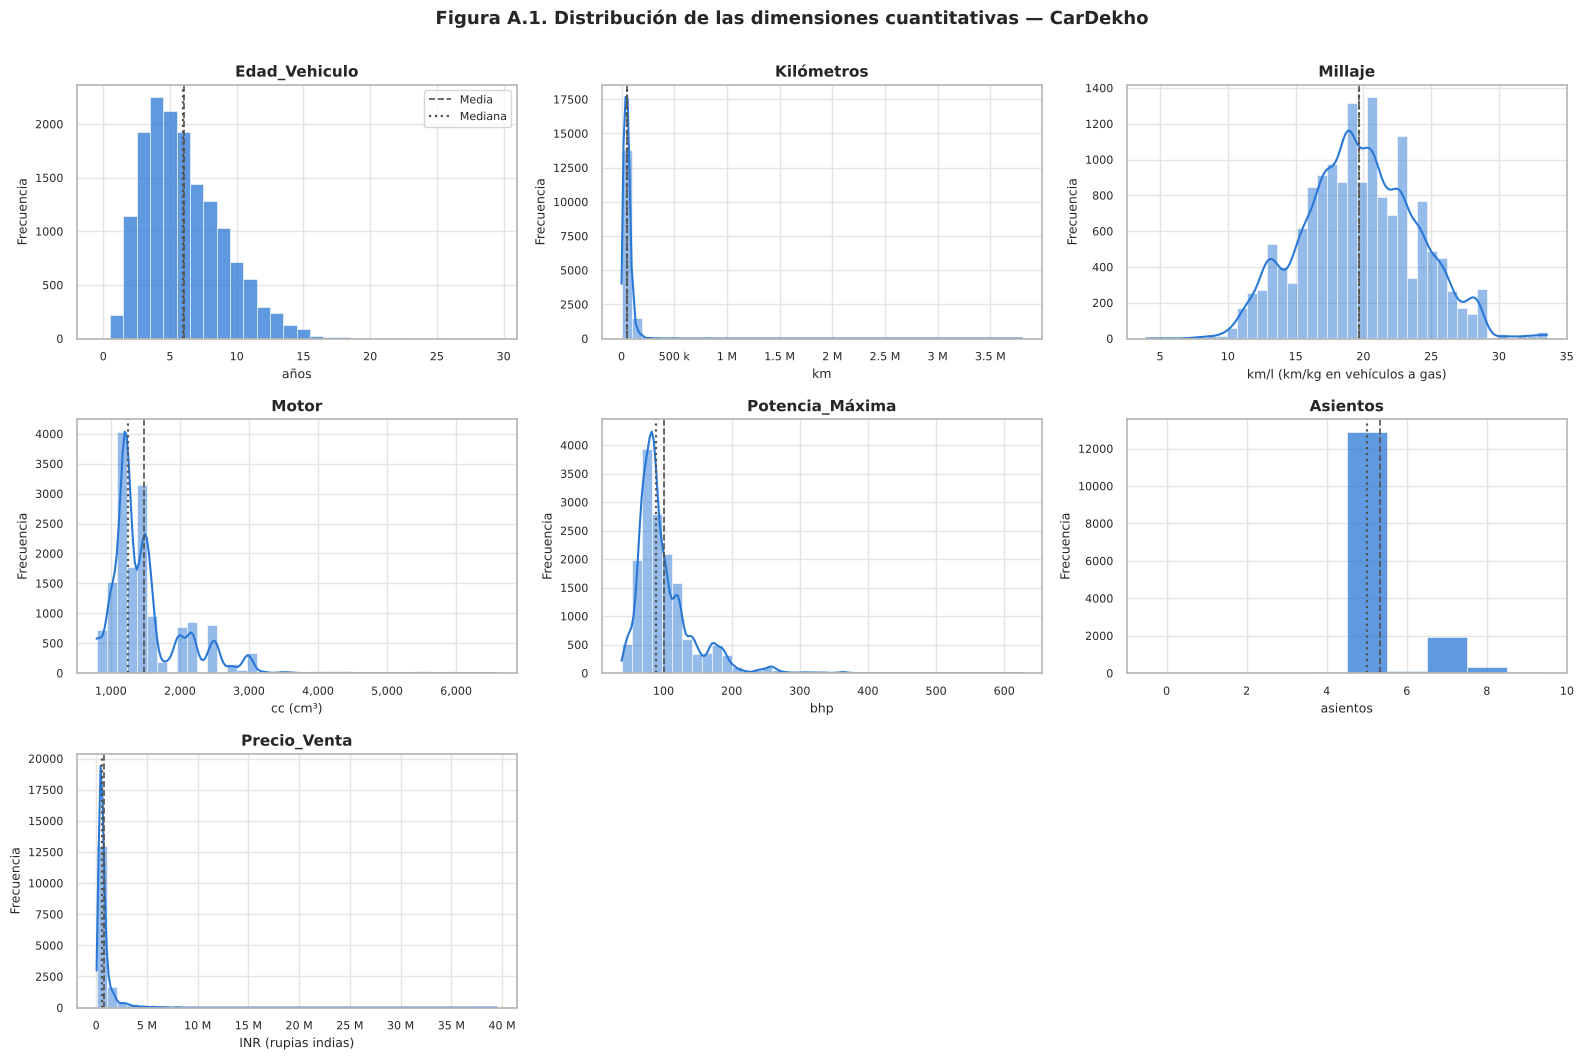

In [22]:
# =====================================================================
# Propósito: distribución de cada dimensión cuantitativa de CarDekho.
# Entrada:   cd[cuant_cd], unidades_cd.
# Salida:    Figura A.1 (figuras/figura_A1_distribucion_cuantitativas_cardekho.png).
# =====================================================================
graficar_distribuciones_cuantitativas(
    cd, cuant_cd, unidades_cd,
    "Figura A.1. Distribución de las dimensiones cuantitativas — CarDekho",
    "figura_A1_distribucion_cuantitativas_cardekho.png")
plt.show()

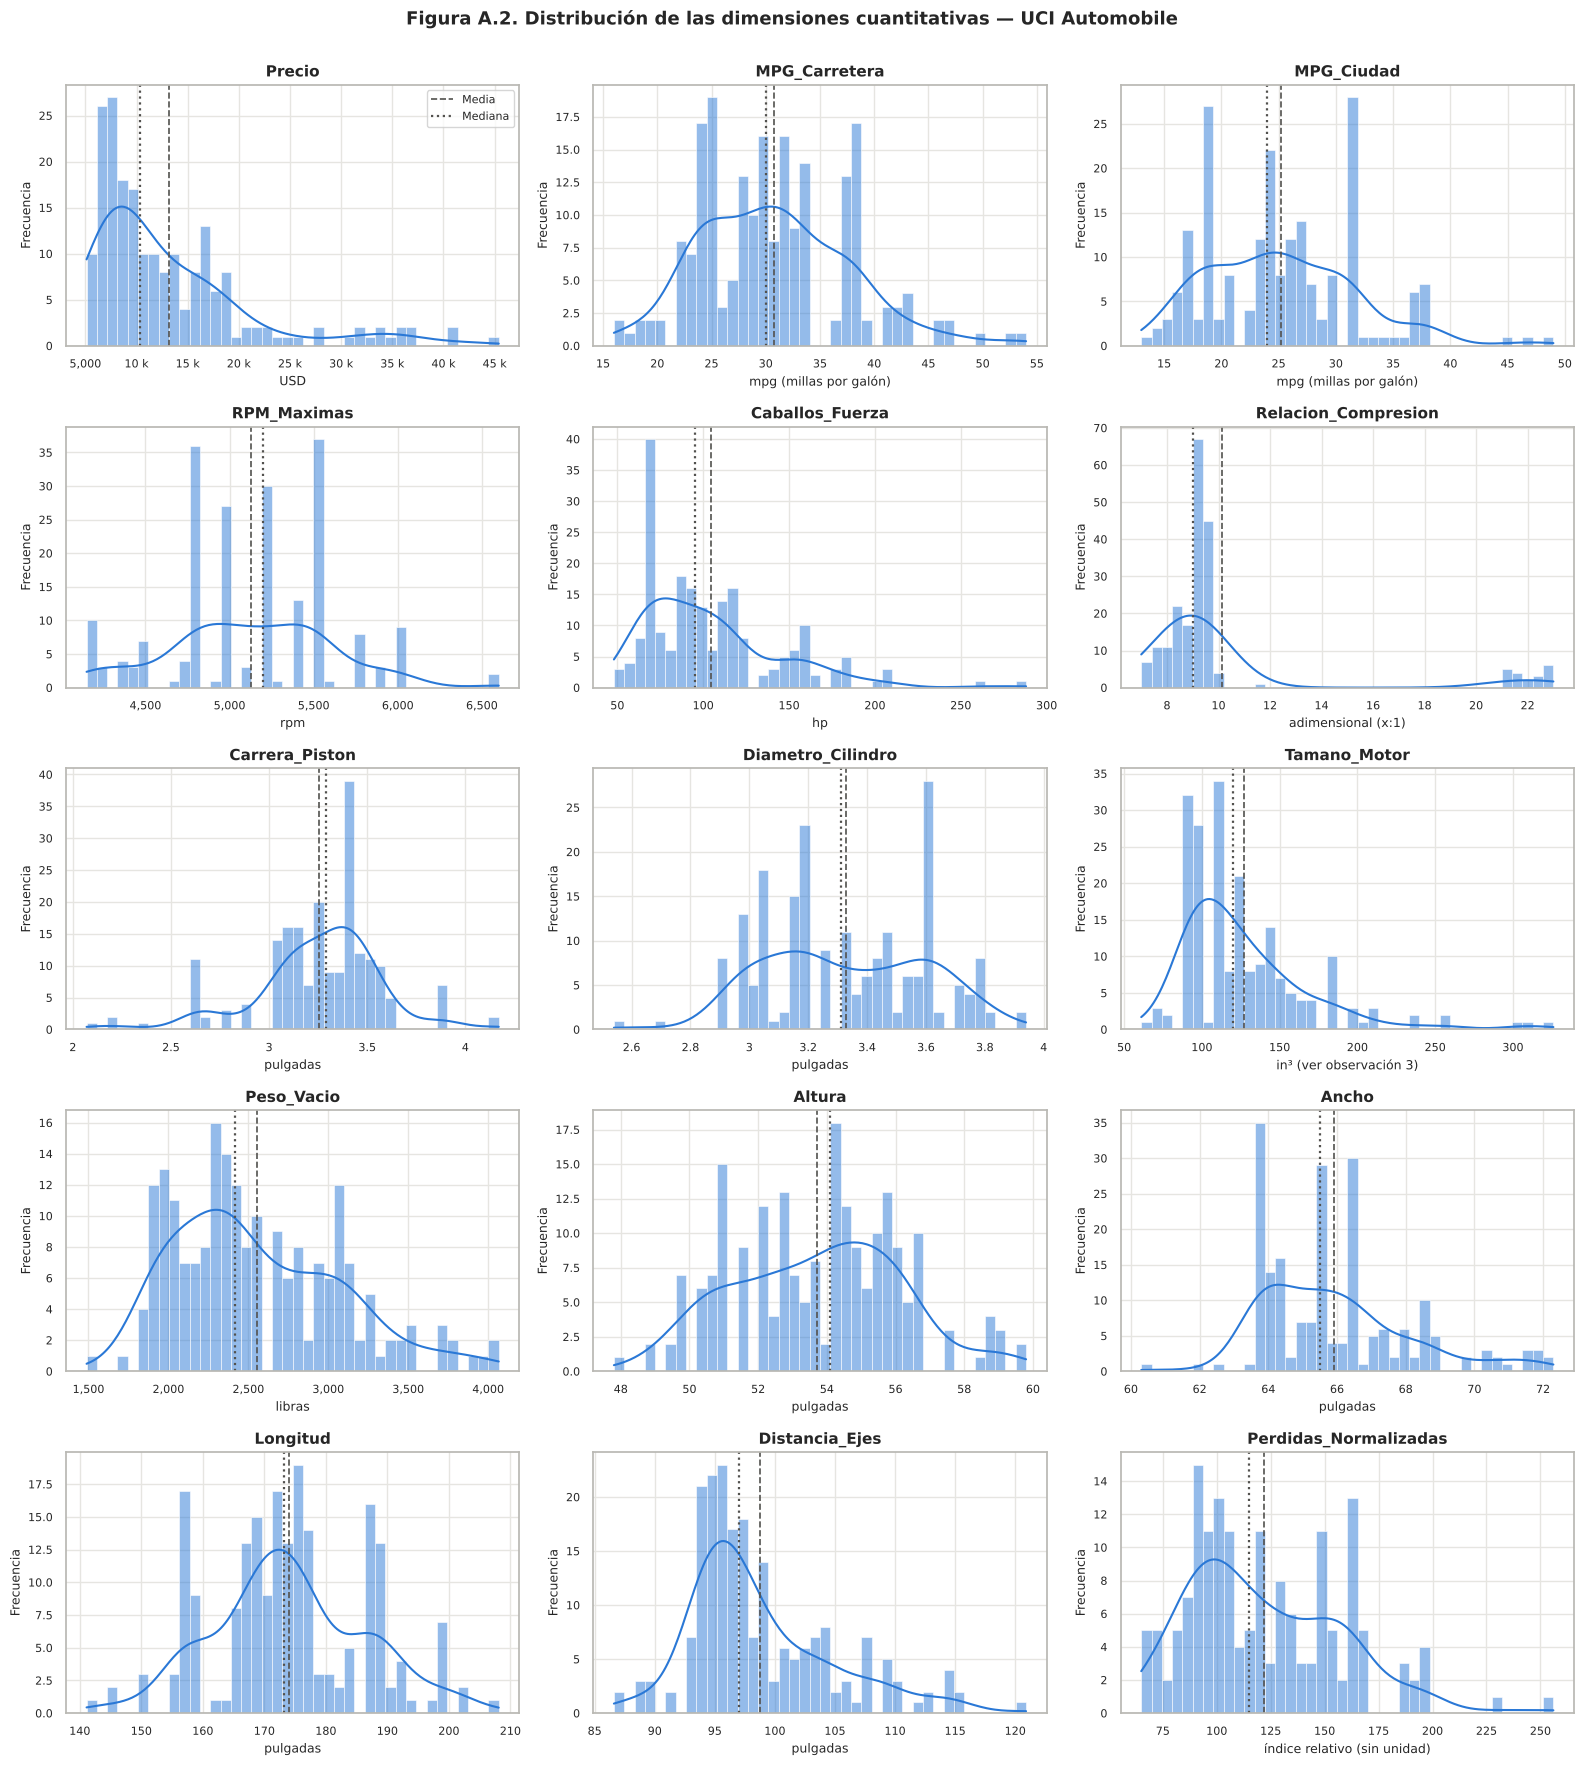

In [23]:
# =====================================================================
# Propósito: distribución de cada dimensión cuantitativa de UCI.
# Entrada:   uci[cuant_uci], unidades_uci.
# Salida:    Figura A.2 (figuras/figura_A2_distribucion_cuantitativas_uci.png).
# =====================================================================
graficar_distribuciones_cuantitativas(
    uci, cuant_uci, unidades_uci,
    "Figura A.2. Distribución de las dimensiones cuantitativas — UCI Automobile",
    "figura_A2_distribucion_cuantitativas_uci.png")
plt.show()

### Análisis bivariado: pairplot
Cada celda compara dos dimensiones cuantitativas con un diagrama de dispersión. La diagonal muestra el histograma de cada dimensión.

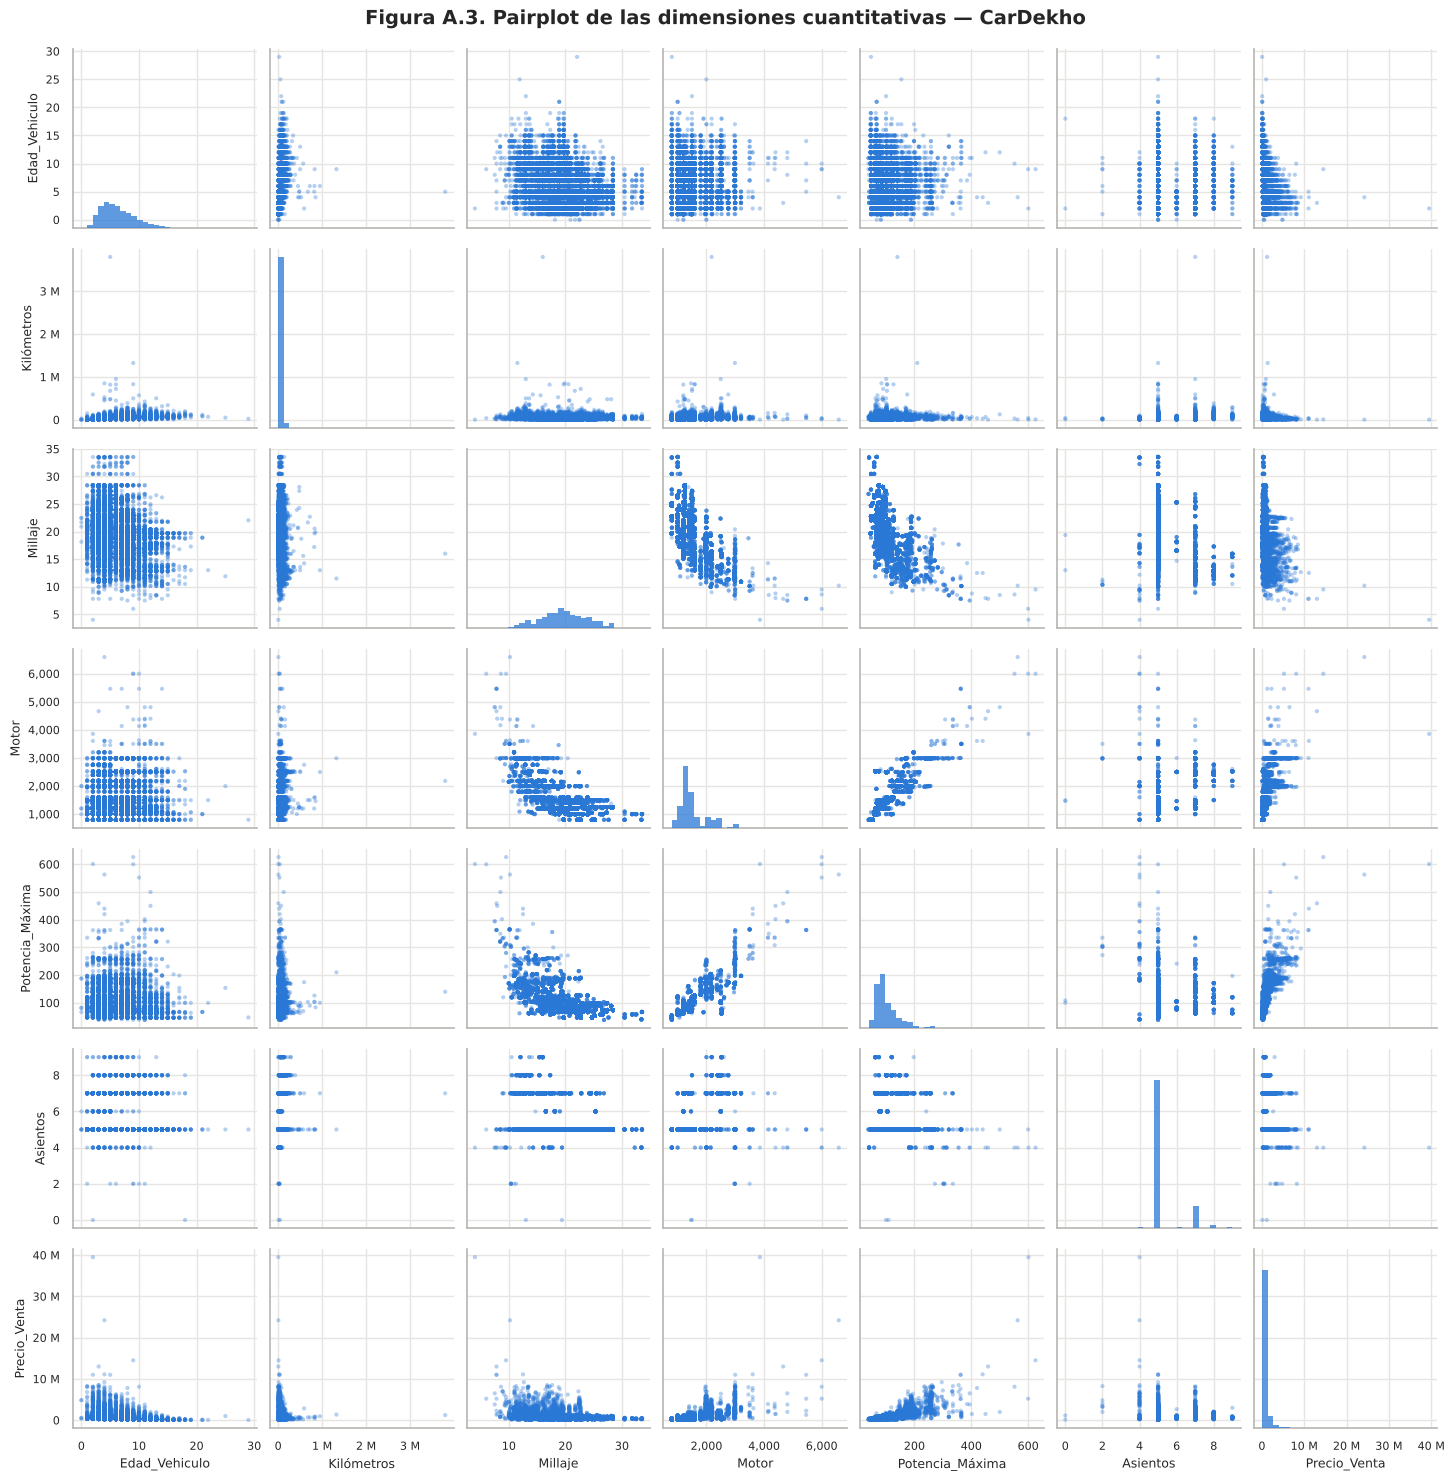

In [24]:
# =====================================================================
# Propósito: pairplot entre las dimensiones cuantitativas de CarDekho.
# Entrada:   cd[cuant_cd].
# Salida:    Figura A.3 (figuras/figura_A3_pairplot_cardekho.png).
# =====================================================================
graficar_pairplot(cd, cuant_cd,
                  "Figura A.3. Pairplot de las dimensiones cuantitativas — CarDekho",
                  "figura_A3_pairplot_cardekho.png", altura=2.1)
plt.show()

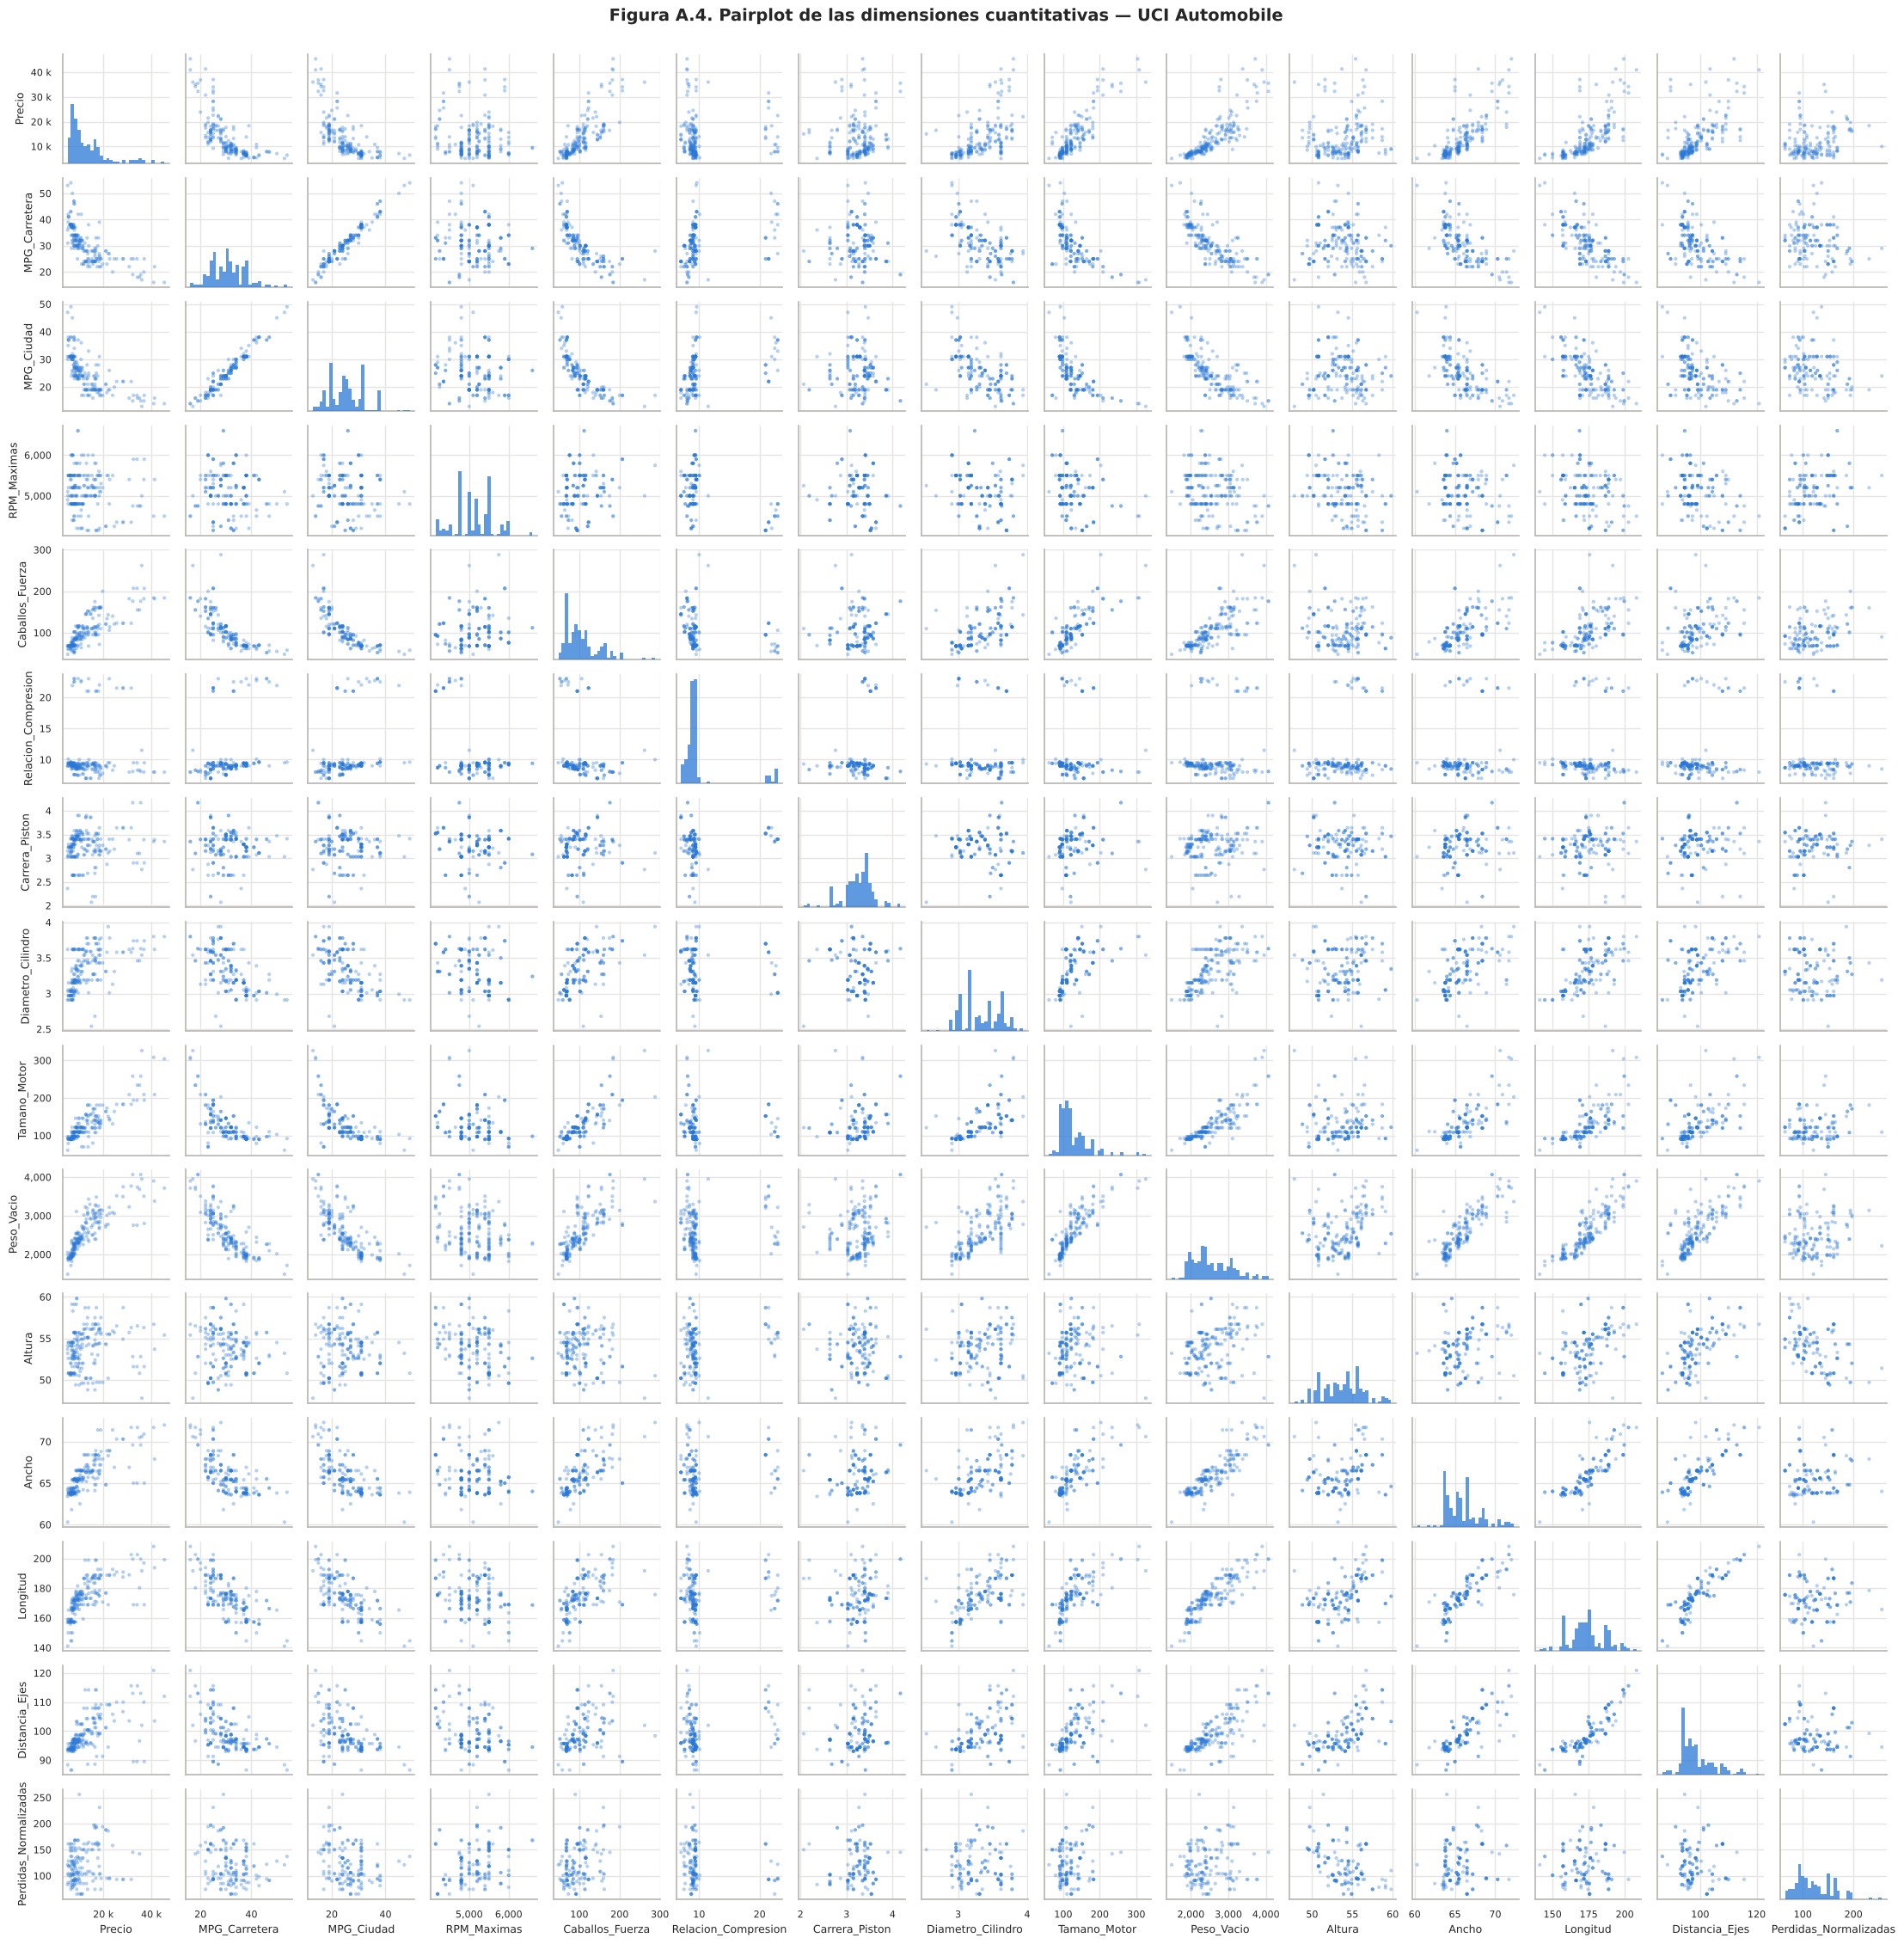

In [25]:
# =====================================================================
# Propósito: pairplot entre las dimensiones cuantitativas de UCI.
# Entrada:   uci[cuant_uci].
# Salida:    Figura A.4 (figuras/figura_A4_pairplot_uci.png).
# =====================================================================
graficar_pairplot(uci, cuant_uci,
                  "Figura A.4. Pairplot de las dimensiones cuantitativas — UCI Automobile",
                  "figura_A4_pairplot_uci.png", altura=1.5)
plt.show()

### Análisis multivariado: mapa de calor de correlaciones
Coeficiente de correlación de Pearson entre todas las dimensiones cuantitativas: +1 indica una relación lineal positiva perfecta, −1 una negativa perfecta y 0 ausencia de relación lineal.

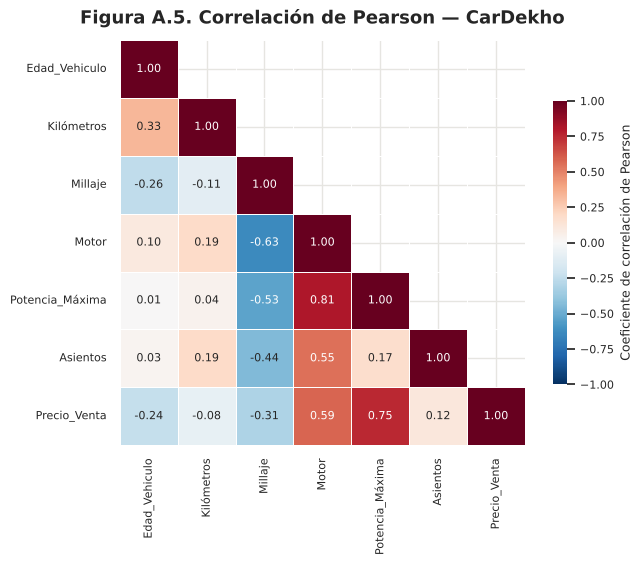

,Correlación con Precio_Venta
Potencia_Máxima,0.750
Motor,0.586
Asientos,0.115
Kilómetros,-0.080
Edad_Vehiculo,-0.242
Millaje,-0.306


In [26]:
# =====================================================================
# Propósito: mapa de calor de correlaciones de CarDekho y correlación
#            de cada dimensión con Precio_Venta.
# Entrada:   cd[cuant_cd].
# Salida:    Figura A.5 (figuras/figura_A5_correlacion_cardekho.png) y tabla.
# =====================================================================
corr_cd = graficar_mapa_calor(cd, cuant_cd,
                              "Figura A.5. Correlación de Pearson — CarDekho",
                              "figura_A5_correlacion_cardekho.png")
plt.show()
corr_cd["Precio_Venta"].drop("Precio_Venta").sort_values(ascending=False).to_frame("Correlación con Precio_Venta")

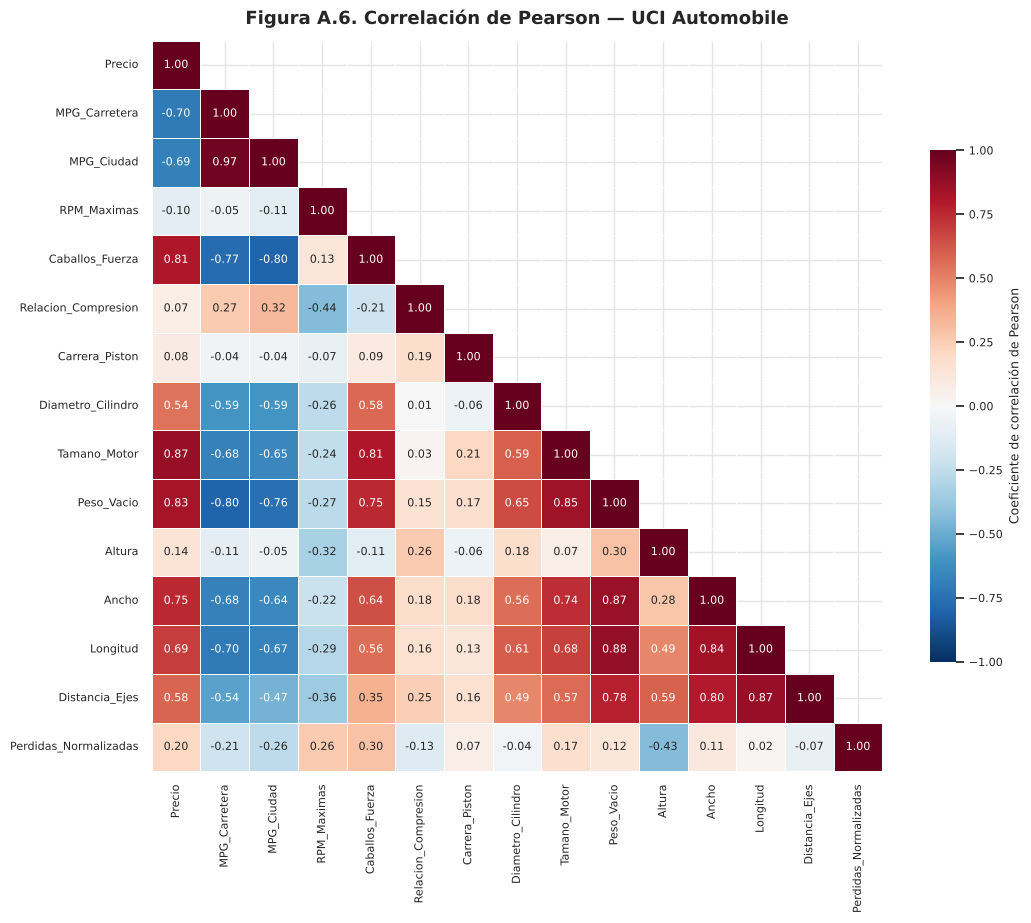

,Correlación con Precio
Tamano_Motor,0.872
Peso_Vacio,0.834
Caballos_Fuerza,0.811
Ancho,0.751
Longitud,0.691
Distancia_Ejes,0.585
Diametro_Cilindro,0.543
Perdidas_Normalizadas,0.203
Altura,0.135
Carrera_Piston,0.082


In [27]:
# =====================================================================
# Propósito: mapa de calor de correlaciones de UCI y correlación de
#            cada dimensión con Precio.
# Entrada:   uci[cuant_uci].
# Salida:    Figura A.6 (figuras/figura_A6_correlacion_uci.png) y tabla.
# =====================================================================
corr_uci = graficar_mapa_calor(uci, cuant_uci,
                               "Figura A.6. Correlación de Pearson — UCI Automobile",
                               "figura_A6_correlacion_uci.png")
plt.show()
corr_uci["Precio"].drop("Precio").sort_values(ascending=False).to_frame("Correlación con Precio")

### Distribución de las dimensiones cualitativas
Frecuencia de cada clase. Las dimensiones con más de 30 clases (Nombre y Modelo) muestran las 30 más frecuentes y agrupan el resto en "Otras"; sus tablas completas están en A.2. Las dimensiones con pocas clases indican el porcentaje encima de cada barra. En UCI se incluyen Num_Puertas y Num_Cilindros porque, al estar guardadas como texto, su distribución se grafica por clase.

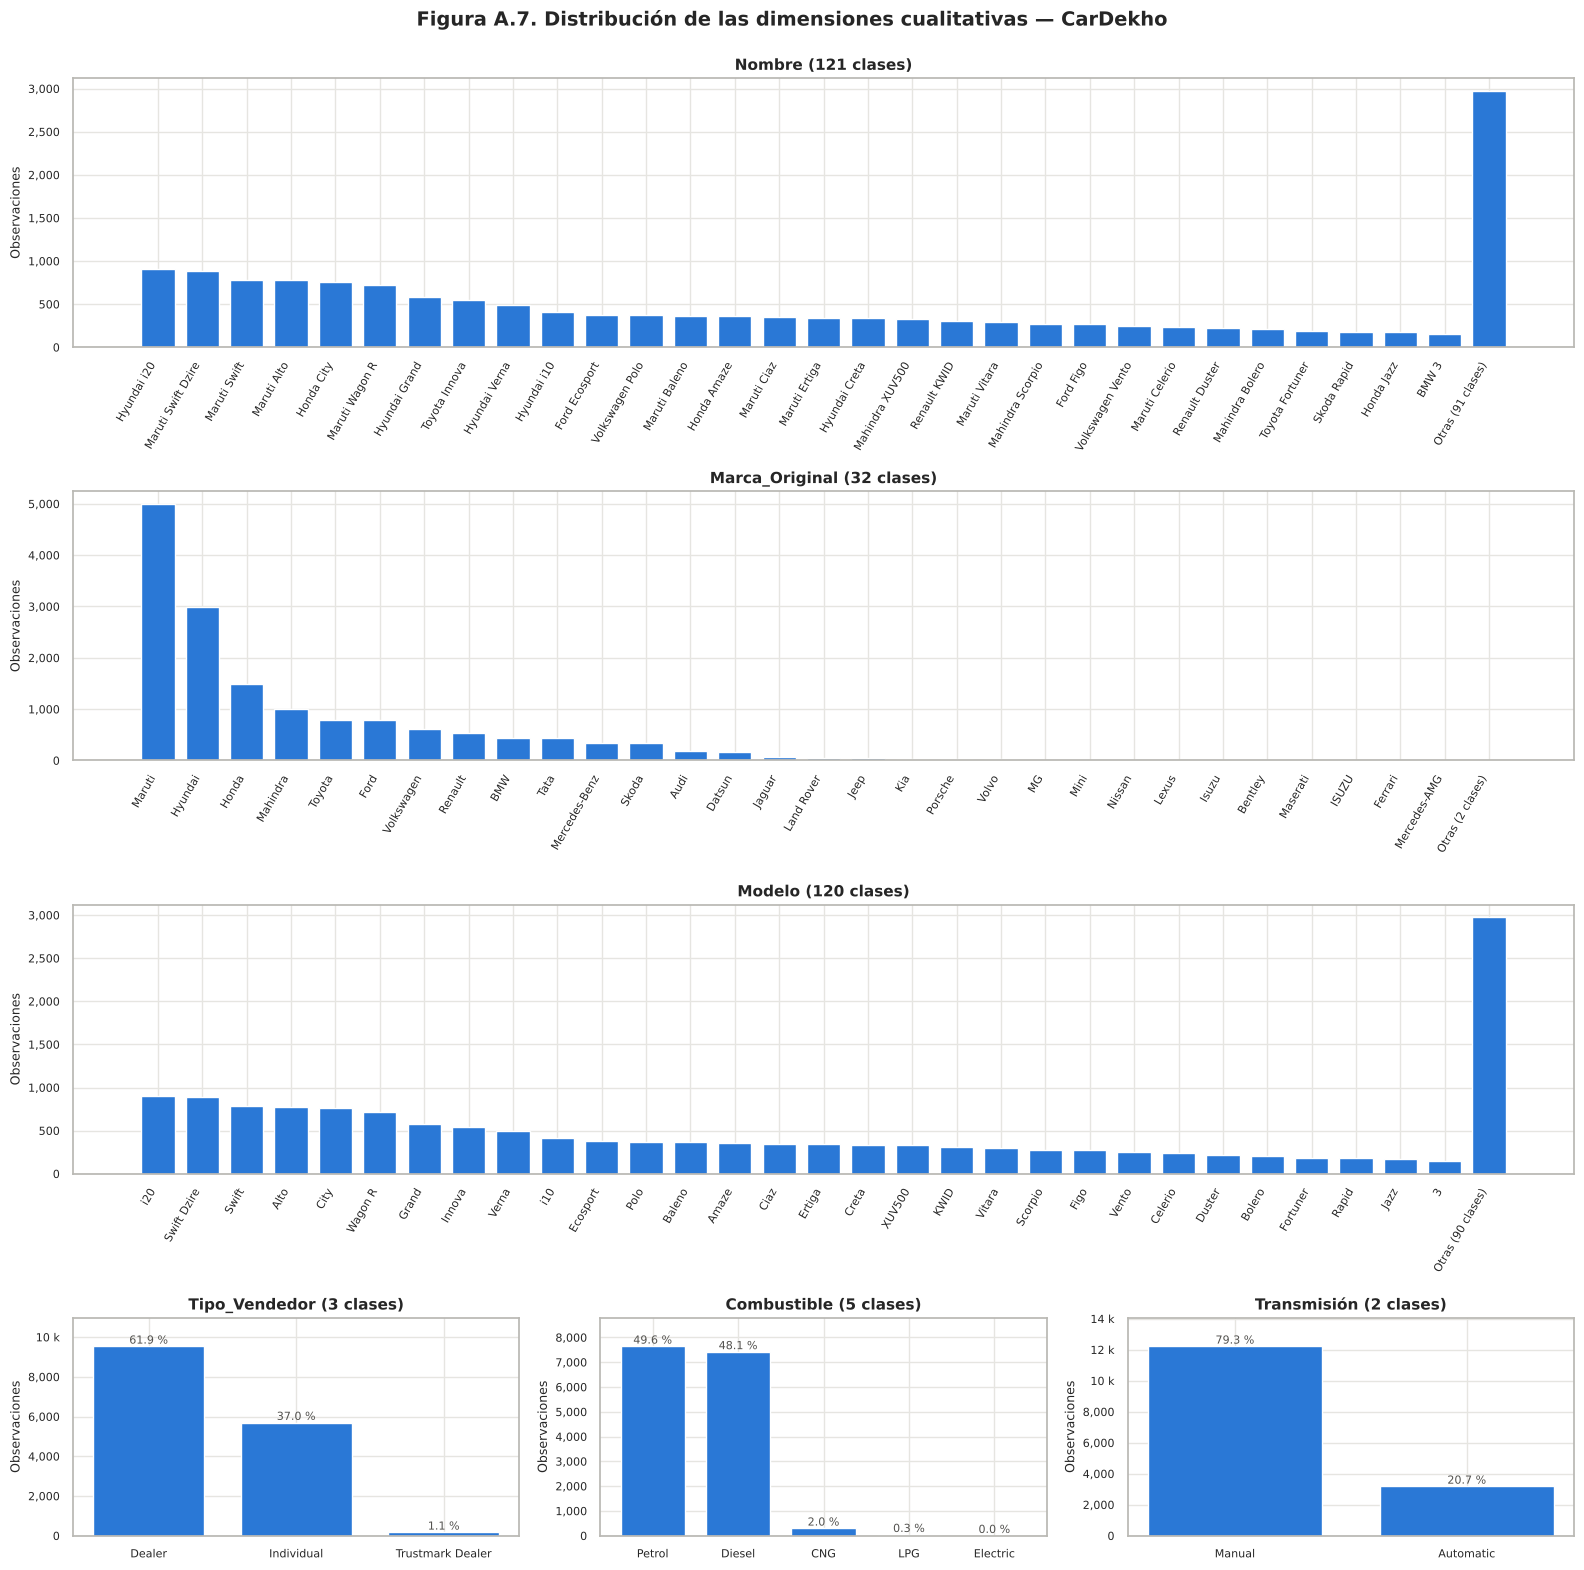

In [28]:
# =====================================================================
# Propósito: distribución de cada dimensión cualitativa de CarDekho.
# Entrada:   cd[cual_cd].
# Salida:    Figura A.7 (figuras/figura_A7_distribucion_cualitativas_cardekho.png).
# =====================================================================
graficar_distribuciones_cualitativas(
    cd, cual_cd,
    "Figura A.7. Distribución de las dimensiones cualitativas — CarDekho",
    "figura_A7_distribucion_cualitativas_cardekho.png")
plt.show()

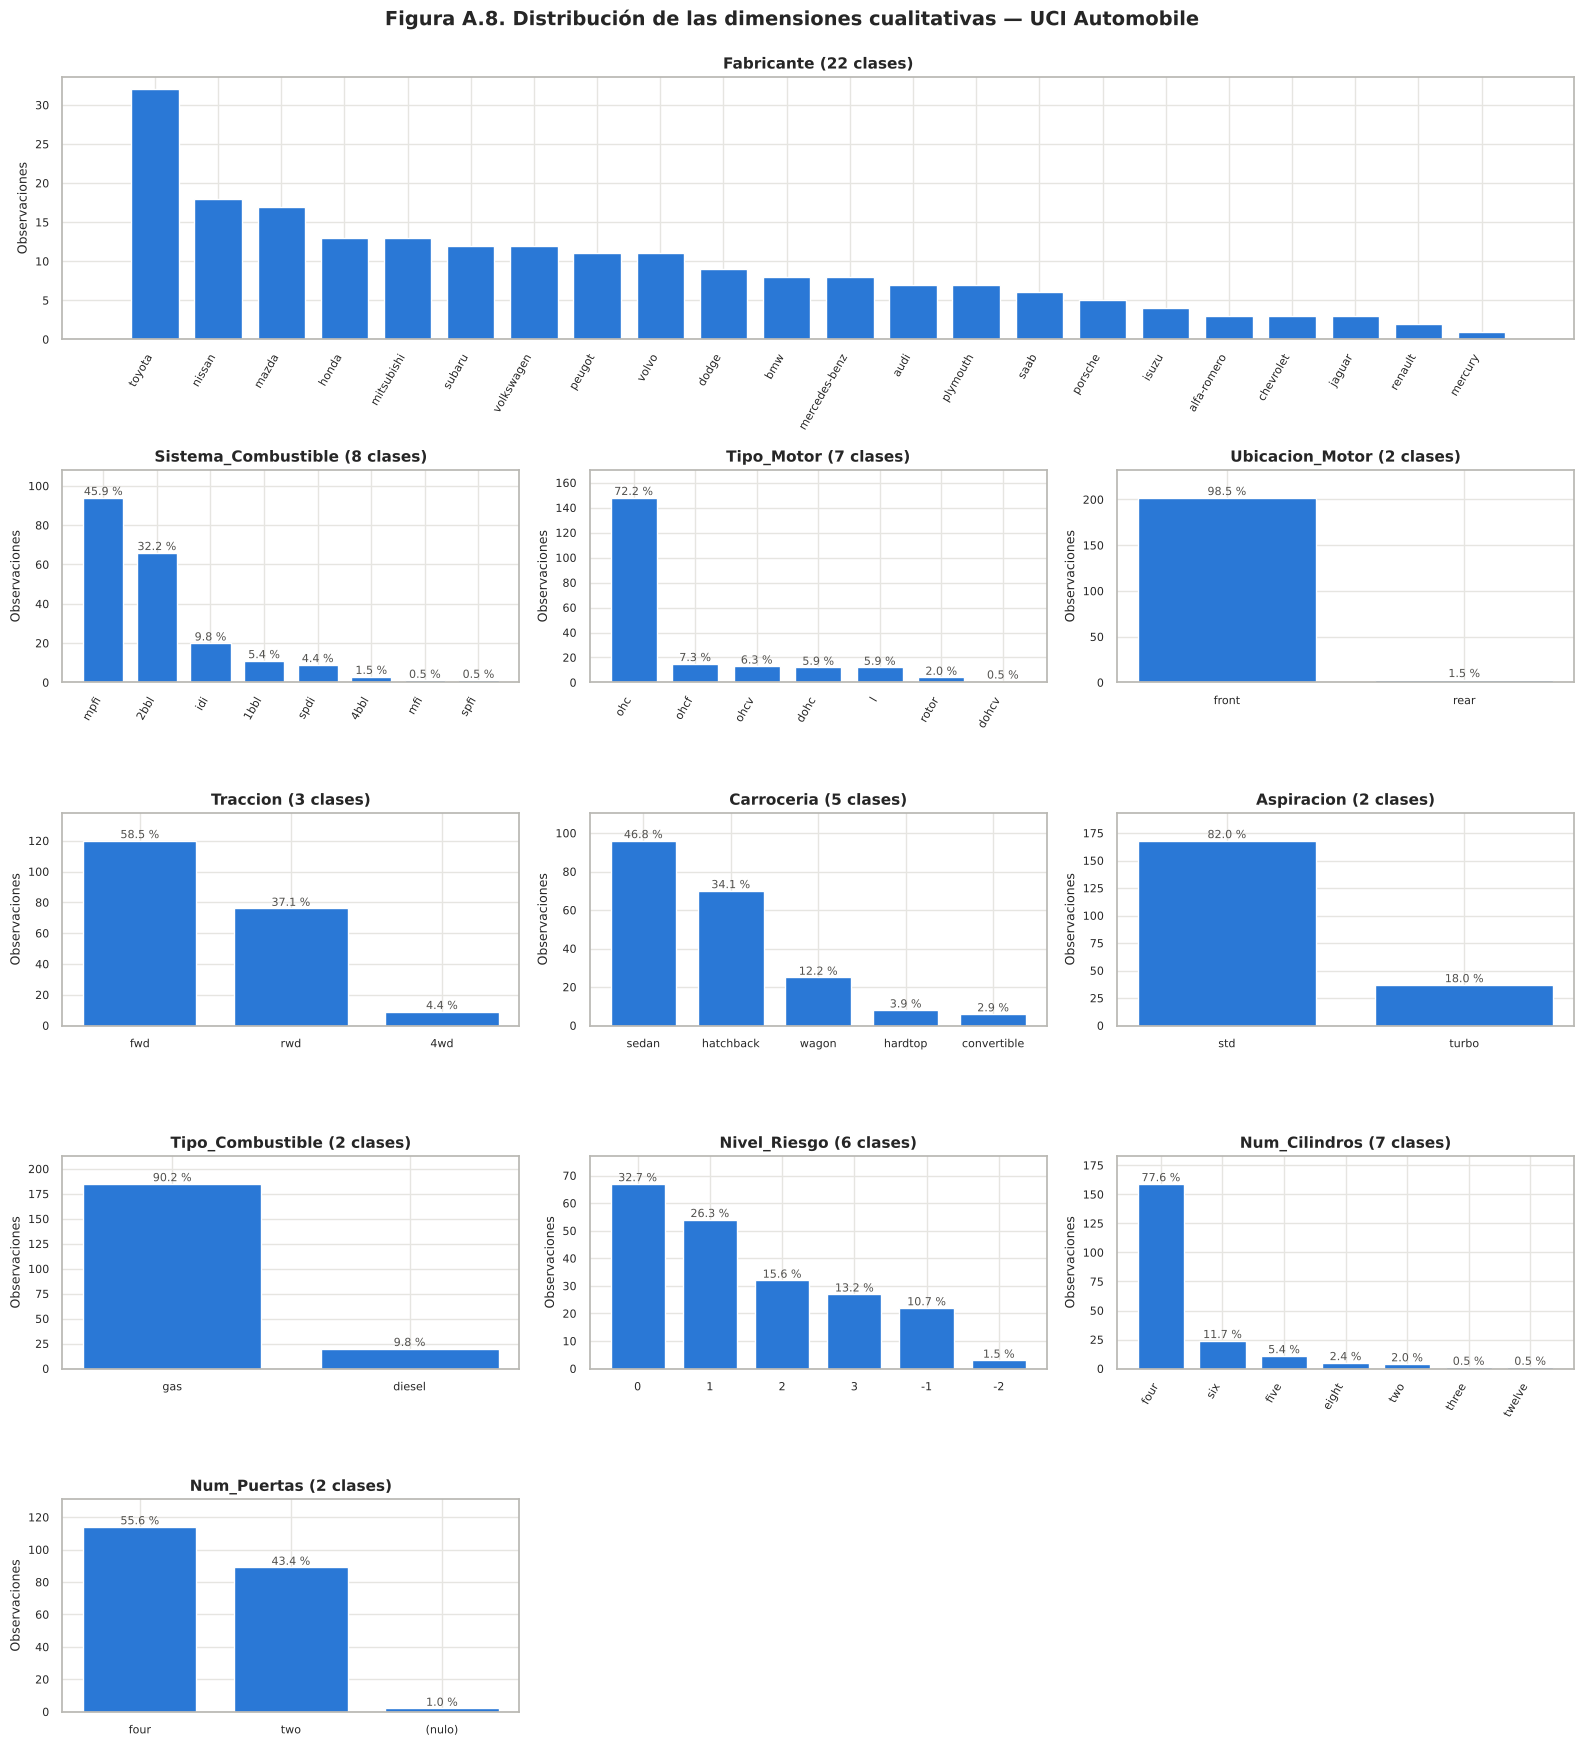

In [29]:
# =====================================================================
# Propósito: distribución de cada dimensión cualitativa de UCI.
# Entrada:   uci[cual_uci + cuant_texto_uci].
# Salida:    Figura A.8 (figuras/figura_A8_distribucion_cualitativas_uci.png).
# =====================================================================
graficar_distribuciones_cualitativas(
    uci, cual_uci + cuant_texto_uci,
    "Figura A.8. Distribución de las dimensiones cualitativas — UCI Automobile",
    "figura_A8_distribucion_cualitativas_uci.png")
plt.show()

### Dimensiones categóricas contra el precio
Las observaciones se agrupan por categoría (eje X) y se ordenan de mayor a menor precio promedio (eje Y). En CarDekho el precio es Precio_Venta (INR) y en UCI es Precio (USD). Las tablas incluyen también el precio mediano y el número de observaciones, porque una categoría con muy pocos registros puede tener un promedio poco representativo. En Nombre y Modelo la gráfica muestra las 30 categorías más caras, pero las tablas están completas.


Nombre vs Precio_Venta (INR)


,Observaciones,Precio promedio,Precio mediano
Nombre,,,
Ferrari GTC4Lusso,1,"39,500,000.000","39,500,000.000"
Rolls-Royce Ghost,1,"24,200,000.000","24,200,000.000"
Bentley Continental,3,"9,266,666.667","8,100,000.000"
Lexus RX,2,"7,100,000.000","7,100,000.000"
Mercedes-Benz GLS,12,"6,781,083.333","6,950,000.000"
Maserati Ghibli,1,"6,200,000.000","6,200,000.000"
Maserati Quattroporte,1,"6,000,000.000","6,000,000.000"
Porsche Macan,2,"5,985,000.000","5,985,000.000"
BMW X4,6,"5,570,000.000","5,600,000.000"



Marca_Original vs Precio_Venta (INR)


,Observaciones,Precio promedio,Precio mediano
Marca_Original,,,
Ferrari,1,"39,500,000.000","39,500,000.000"
Rolls-Royce,1,"24,200,000.000","24,200,000.000"
Bentley,3,"9,266,666.667","8,100,000.000"
Maserati,2,"6,100,000.000","6,100,000.000"
Porsche,21,"5,161,190.476","5,000,000.000"
Lexus,10,"5,146,500.000","4,600,000.000"
Mercedes-AMG,1,"5,100,000.000","5,100,000.000"
Land Rover,51,"3,823,901.961","3,400,000.000"
Volvo,20,"3,729,700.000","3,750,000.000"



Modelo vs Precio_Venta (INR)


...

,Observaciones,Precio promedio,Precio mediano
Tipo_Vendedor,,,
Dealer,9539,"872,505.504","591,000.000"
Individual,5699,"617,880.483","507,000.000"
Trustmark Dealer,173,"571,959.538","540,000.000"



Combustible vs Precio_Venta (INR)


,Observaciones,Precio promedio,Precio mediano
Combustible,,,
Electric,4,"1,853,500.000","1,857,500.000"
Diesel,7419,"1,000,469.335","700,000.000"
Petrol,7643,"572,861.949","460,000.000"
CNG,301,"417,687.708","370,000.000"
LPG,44,"206,272.727","182,500.000"



Transmisión vs Precio_Venta (INR)


,Observaciones,Precio promedio,Precio mediano
Transmisión,,,
Automatic,3186,"1,579,556.811","1,057,000.000"
Manual,12225,"565,285.225","500,000.000"


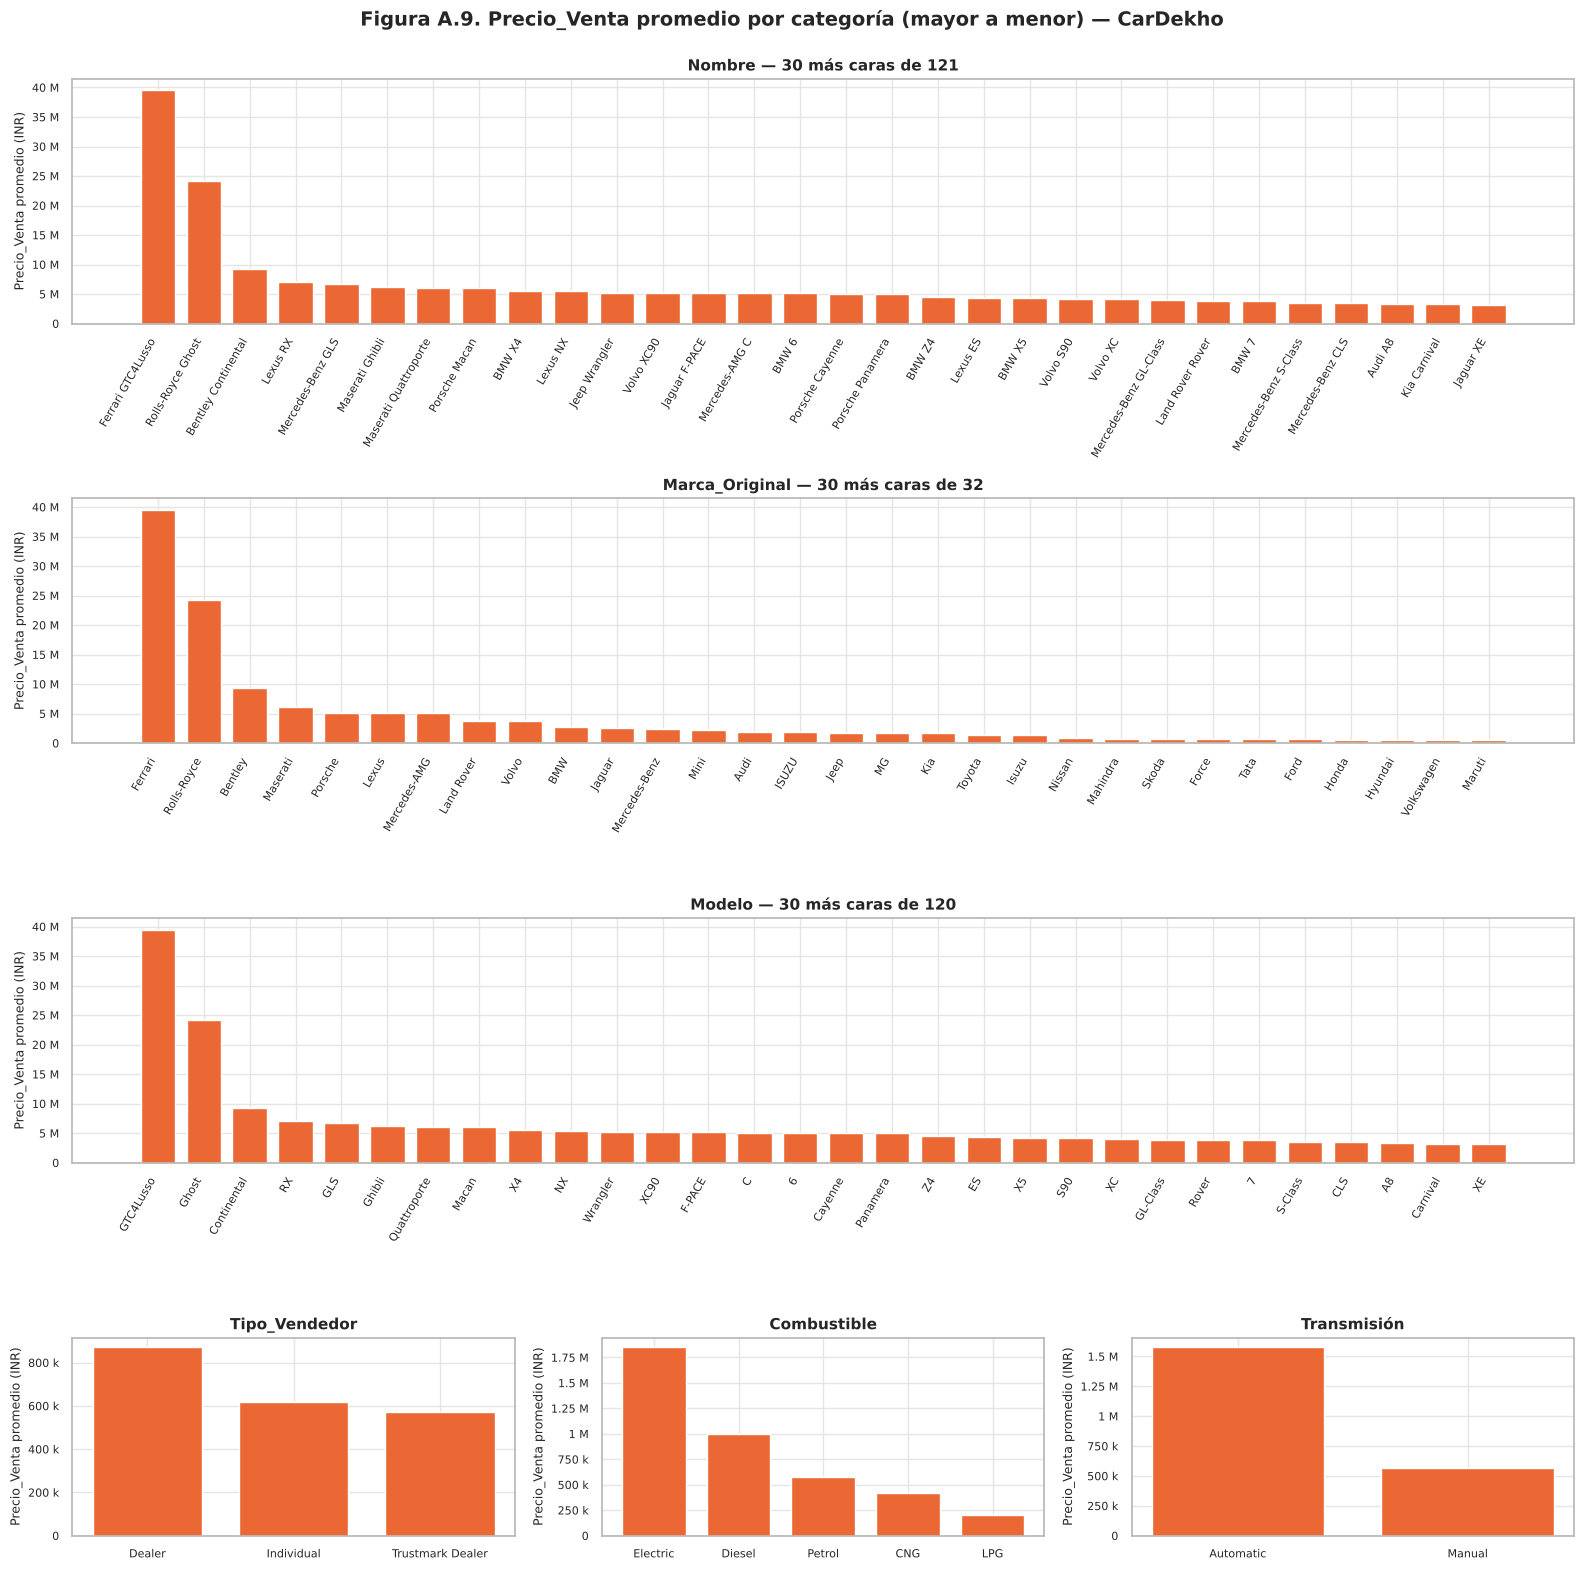

In [30]:
# =====================================================================
# Propósito: comparar cada dimensión categórica de CarDekho contra
#            Precio_Venta, agrupando y ordenando de mayor a menor.
# Entrada:   cd[cual_cd + ["Precio_Venta"]].
# Salida:    tablas por dimensión y Figura A.9
#            (figuras/figura_A9_categoricas_vs_precio_cardekho.png).
# =====================================================================
for col in cual_cd:
    print(f"\n{col} vs Precio_Venta (INR)")
    display(precio_por_categoria(cd, col, "Precio_Venta"))
graficar_categorias_vs_precio(
    cd, cual_cd, "Precio_Venta", "INR",
    "Figura A.9. Precio_Venta promedio por categoría (mayor a menor) — CarDekho",
    "figura_A9_categoricas_vs_precio_cardekho.png")
plt.show()


Sistema_Combustible vs Precio (USD)


,Observaciones,Precio promedio,Precio mediano
Sistema_Combustible,,,
mpfi,92,"17,605.141","15,867.500"
idi,20,"15,838.150","13,852.500"
mfi,1,"12,964.000","12,964.000"
4bbl,3,"12,145.000","11,845.000"
spfi,1,"11,048.000","11,048.000"
spdi,9,"10,990.444","9,959.000"
1bbl,11,"7,555.545","7,295.000"
2bbl,64,"7,433.203","7,324.000"



Tipo_Motor vs Precio (USD)


,Observaciones,Precio promedio,Precio mediano
Tipo_Motor,,,
ohcv,13,"25,098.385","19,699.000"
dohc,12,"18,116.417","16,249.000"
l,12,"14,627.583","16,105.000"
ohcf,15,"13,738.600","9,233.000"
rotor,4,"13,020.000","12,745.000"
ohc,145,"11,567.359","9,095.000"
dohcv,0,NaN,NaN



Ubicacion_Motor vs Precio (USD)


...

,Observaciones,Precio promedio,Precio mediano
Nivel_Riesgo,,,
-1,22,"17,330.682","16,132.500"
3,27,"17,221.296","14,869.000"
-2,3,"15,781.667","15,985.000"
0,65,"14,397.092","11,259.000"
2,32,"10,109.281","8,995.000"
1,52,"9,648.654","7,447.000"



Num_Cilindros vs Precio (USD)


,Observaciones,Precio promedio,Precio mediano
Num_Cilindros,,,
eight,4,"38,900.000","38,008.000"
twelve,1,"36,000.000","36,000.000"
six,24,"23,671.833","21,037.500"
five,10,"22,007.600","21,397.500"
two,4,"13,020.000","12,745.000"
four,157,"10,303.197","8,949.000"
three,1,"5,151.000","5,151.000"



Num_Puertas vs Precio (USD)


,Observaciones,Precio promedio,Precio mediano
Num_Puertas,,,
four,113,"13,565.673","11,245.000"
two,86,"12,818.128","9,927.000"


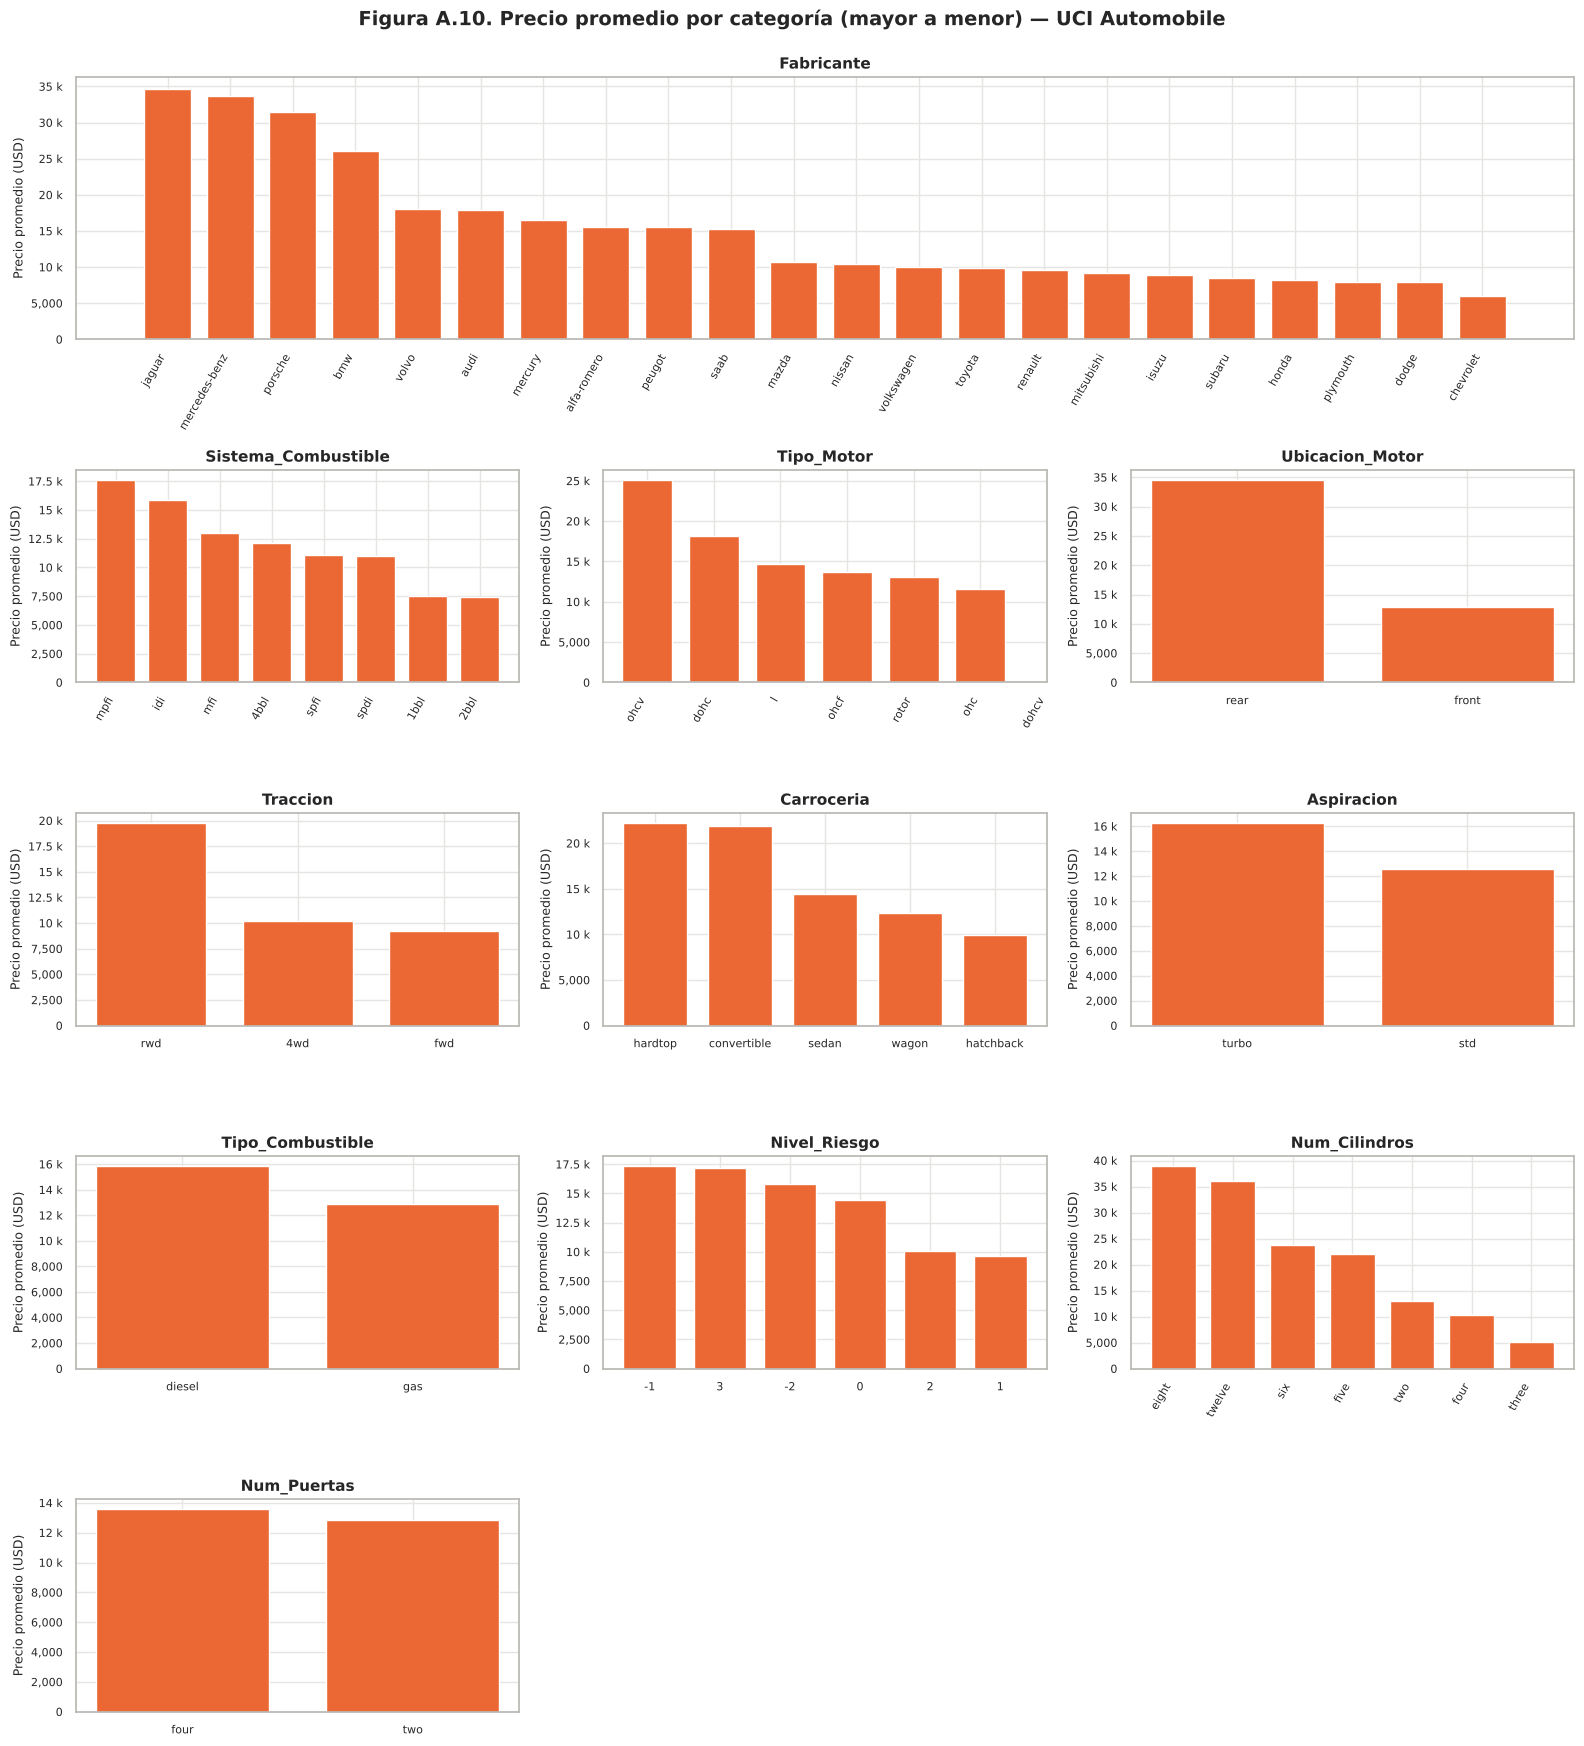

In [31]:
# =====================================================================
# Propósito: comparar cada dimensión categórica de UCI contra Precio,
#            agrupando y ordenando de mayor a menor.
# Entrada:   uci[cual_uci + cuant_texto_uci + ["Precio"]].
# Salida:    tablas por dimensión y Figura A.10
#            (figuras/figura_A10_categoricas_vs_precio_uci.png).
# =====================================================================
for col in cual_uci + cuant_texto_uci:
    print(f"\n{col} vs Precio (USD)")
    display(precio_por_categoria(uci, col, "Precio"))
graficar_categorias_vs_precio(
    uci, cual_uci + cuant_texto_uci, "Precio", "USD",
    "Figura A.10. Precio promedio por categoría (mayor a menor) — UCI Automobile",
    "figura_A10_categoricas_vs_precio_uci.png")
plt.show()

### Conclusiones A.3
Distribuciones cuantitativas (Figuras A.1 y A.2)
- En CarDekho, Precio_Venta, Kilómetros, Potencia_Máxima y Motor tienen sesgo positivo: la media queda a la derecha de la mediana y hay valores extremos aislados.
- El caso más fuerte es Precio_Venta, cuyo histograma se concentra por debajo de 2 M INR. Esto justifica transformarla, por ejemplo con logaritmo (inciso 25).
- Millaje es prácticamente simétrica y Asientos se concentra en 5 y 7.
- Motor es multimodal: se agrupa en cilindradas comerciales comunes (cerca de 1,200, 1,500, 2,000 y 3,000 cc).
- En UCI, Precio también es asimétrica a la derecha y Relacion_Compresion es bimodal: la gasolina se ubica alrededor de 9 y el diésel arriba de 20.

Pairplot (Figuras A.3 y A.4)
- En CarDekho hay una relación positiva clara entre Motor y Potencia_Máxima, y entre Potencia_Máxima y Precio_Venta. Millaje tiene una relación negativa con Motor y Potencia_Máxima: los motores grandes rinden menos.
- El precio tiende a bajar con la edad del vehículo.
- Los valores atípicos (3.8 M km y 39.5 M INR) aparecen aislados y comprimen el resto de las nubes de puntos.
- En UCI, las dimensiones de tamaño (Peso_Vacio, Longitud, Ancho y Distancia_Ejes) forman nubes casi lineales entre sí. La relación entre Precio y MPG es inversa y curva, no lineal.

Correlaciones (Figuras A.5 y A.6)
- En CarDekho, Precio_Venta se correlaciona sobre todo con Potencia_Máxima (0.75) y Motor (0.59), y de forma negativa con Millaje (−0.31) y Edad_Vehiculo (−0.24).
- Kilómetros casi no se relaciona linealmente con el precio (−0.08), en parte por sus valores extremos.
- Motor y Potencia_Máxima están muy correlacionadas entre sí (0.81).
- En UCI, Precio se correlaciona con Tamano_Motor (0.87), Peso_Vacio (0.83), Caballos_Fuerza (0.81) y Ancho (0.75), y de forma negativa con MPG_Carretera (−0.70) y MPG_Ciudad (−0.69).
- MPG_Ciudad y MPG_Carretera (0.97) son casi redundantes. Esta multicolinealidad debe considerarse al elegir variables.

Distribuciones cualitativas (Figuras A.7 y A.8)
- Confirman el desbalance visto en A.2: pocas clases concentran la mayoría de las observaciones y muchas tienen frecuencias casi nulas.

Categóricas contra el precio (Figuras A.9 y A.10)
- En CarDekho, el precio promedio lo encabezan las marcas de lujo. Ferrari y Rolls-Royce tienen 1 registro cada una, así que su promedio no es representativo; la tabla con el número de observaciones permite distinguir esos casos.
- Los automáticos promedian unas 2.8 veces el precio de los manuales.
- Por combustible, el orden es diésel, gasolina, GNC y GLP. Electric queda arriba, pero con solo 4 registros.
- En UCI encabezan jaguar, mercedes-benz, porsche y bmw. Los autos con motor trasero (solo 3 registros), tracción trasera, 8 o 12 cilindros, diésel o turbo tienen precios promedio mayores.
- dohcv aparece sin barra porque su único registro no tiene precio.